# Privacy-Preserving Federated Learning: Comparison Analysis

Modes included:
- **baseline** — No privacy (FedAvg)
- **he_tenseal** — HE-TenSEAL (CKKS approximate homomorphic encryption)
- **he_concrete_tfhe** — HE-Concrete TFHE (exact boolean-circuit FHE)
- **zkp** — Zero-Knowledge Proofs (gnark Groth16 zk-SNARK, all layers)
- **zkp_sampled** — ZKP with sampled-layer proofs
- **dp** — Differential Privacy (Gaussian noise, Opacus)
- **he_tenseal_zkp** — Hybrid: HE-TenSEAL + ZKP integrity proofs
- **he_concrete_tfhe_zkp** — Hybrid: HE-Concrete TFHE + ZKP integrity proofs
- **he_tenseal_zkp_dp** — Hybrid: HE-TenSEAL + ZKP + DP
- **he_concrete_tfhe_zkp_dp** — Hybrid: HE-Concrete TFHE + ZKP + DP

**Datasets:** Healthcare · Credit Card · Stock · MNIST · CIFAR-10

All results are loaded from `results/<dataset>/comparison_report.json` which is updated automatically after each `compare.py` run.


In [23]:
# Helper: load cleaned comparison report
import json, os
from pathlib import Path

def load_report(dataset):
    p = Path(f'results/{dataset}/comparison_report.json')
    if not p.exists():
        print('Report missing:', p)
        return None
    with open(p, 'r') as f:
        return json.load(f)

# Example: report = load_report('creditcard')
# print(len(report) if isinstance(report, list) else report.keys())

# Privacy-Preserving Federated Learning: Comprehensive Comparison Analysis

This notebook provides a detailed comparison of privacy-preserving methods in federated learning:
1. **Baseline** — No privacy (plain FedAvg)
2. **DP** — Differential Privacy (Gaussian noise, Opacus). Formal epsilon-delta privacy guarantee; small accuracy degradation.
3. **ZKP** — Zero-Knowledge Proofs (gnark Groth16 zk-SNARK). Proves gradient integrity without revealing values.
4. **ZKP-Sampled** — ZKP with sampled-layer proofs for lower prover cost per round.
5. **HE-TenSEAL** — CKKS Approximate Homomorphic Encryption (TenSEAL). Packs entire weight vectors into CKKS ciphertexts using SIMD-style batching (BatchCrypt approach). Approximate arithmetic; small decryption noise around 1e-9.
6. **HE-Concrete-TFHE** — Exact FHE with quantized boolean circuits (Concrete ML). Up to 32x larger ciphertexts than CKKS, exact arithmetic.
7. **HE-TenSEAL + ZKP** — Hybrid: CKKS encryption for confidentiality + ZKP for integrity verification.
8. **HE-Concrete-TFHE + ZKP** — Hybrid: exact FHE confidentiality + ZKP integrity.
9. **HE-TenSEAL + ZKP + DP** — Hybrid confidentiality + integrity + formal differential privacy.
10. **HE-Concrete-TFHE + ZKP + DP** — Maximum-assurance hybrid with exact FHE, ZKP, and DP.

**Datasets:**
- **Healthcare** — Heart Disease Prediction (918 samples, 13 features, binary classification)
- **Credit Card** — Credit Card Fraud Detection (284,807 transactions, 0.17% fraud rate, binary; AUPRC is primary metric due to severe class imbalance)
- **Stock** — Stock Market Prediction (3,180 samples, 11 features)
- **MNIST** — Handwritten digit classification (10 classes, grayscale images)
- **CIFAR-10** — Natural image classification (10 classes, RGB images)

**Author:** TxCorpi0x | Last results: 2026-03-22


## 0. Theoretical Background (Cryptographic Context)

This section provides the formal mathematical and threat-model context for the 10 privacy modes benchmarked in this notebook:

- **baseline** — No privacy (FedAvg)
- **he_tenseal** — HE-TenSEAL (CKKS approximate homomorphic encryption)
- **he_concrete_tfhe** — HE-Concrete TFHE (exact boolean-circuit FHE)
- **zkp** — Zero-Knowledge Proofs (gnark Groth16 zk-SNARK, all layers)
- **zkp_sampled** — ZKP with sampled-layer proofs
- **dp** — Differential Privacy (Gaussian noise, Opacus)
- **he_tenseal_zkp** — Hybrid: HE-TenSEAL + ZKP integrity proofs
- **he_concrete_tfhe_zkp** — Hybrid: HE-Concrete TFHE + ZKP integrity proofs
- **he_tenseal_zkp_dp** — Hybrid: HE-TenSEAL + ZKP + DP
- **he_concrete_tfhe_zkp_dp** — Hybrid: HE-Concrete TFHE + ZKP + DP

**Datasets:** Healthcare · Credit Card · Stock · MNIST · CIFAR-10

---

### 1. Threat Model and Security Objectives

The FL setting in this notebook assumes two primary adversary classes:

1. **Honest-but-curious aggregator**: follows protocol but attempts to infer private training data from client updates.
2. **Malicious (Byzantine) client**: can submit manipulated gradients to poison or backdoor global training.

Corresponding cryptographic goals:

1. **Confidentiality**: hide plaintext gradients/weights from server and external observers.
2. **Integrity / correctness**: prove client updates satisfy protocol constraints.
3. **Formal statistical privacy**: bound individual contribution leakage with epsilon-delta guarantees.

The evaluated methods map to these goals as follows:

1. **Baseline** — No privacy (plain FedAvg)
2. **DP** — Differential Privacy (Gaussian noise, Opacus). Formal epsilon-delta privacy guarantee; small accuracy degradation.
3. **ZKP** — Zero-Knowledge Proofs (gnark Groth16 zk-SNARK). Proves gradient integrity without revealing values.
4. **ZKP-Sampled** — ZKP with sampled-layer proofs for lower prover cost per round.
5. **HE-TenSEAL** — CKKS approximate homomorphic encryption for encrypted aggregation.
6. **HE-Concrete-TFHE** — exact FHE aggregation via boolean-circuit cryptography.
7. **HE-TenSEAL + ZKP** — Hybrid: CKKS encryption for confidentiality + ZKP for integrity verification.
8. **HE-Concrete-TFHE + ZKP** — Hybrid: exact FHE confidentiality + ZKP integrity.
9. **HE-TenSEAL + ZKP + DP** — Hybrid confidentiality + integrity + formal differential privacy.
10. **HE-Concrete-TFHE + ZKP + DP** — Maximum-assurance hybrid with exact FHE, ZKP, and DP.

---

### 1A. Threat Landscape in Federated Learning

The table below maps major FL attack classes to corresponding defenses benchmarked in this work.

| Attack Class | Adversary | Mechanism | Primary Mitigation in This Framework |
|--------------|-----------|-----------|--------------------------------------|
| **Gradient Inversion / Reconstruction** | Honest-but-curious server | Adversary optimises dummy inputs to match received gradients, recovering training samples (Zhu et al. 2019; Geiping et al. 2021) | HE (server sees only ciphertexts); DP (gradients randomised before upload) |
| **Membership Inference** | Server or external | Adversary distinguishes whether a target record was in a client's training set by probing the global model (Shokri et al., IEEE S&P 2017) | DP (noise obfuscates individual contributions); HE (model gradient opaque on server) |
| **Byzantine / Poisoning** | Malicious client | A colluding client submits crafted gradients designed to skew the global model or embed a backdoor — persists even under HE, since the encrypted update can be maliciously formed | ZKP (proves updates satisfy arithmetic validity constraints e.g., bounded L2 norm, correct local SGD step) |

The **honest-but-curious (semi-honest)** adversary model assumes the server executes the protocol faithfully but attempts to learn private information from messages it observes. HE is the canonical defence here. The **malicious** adversary model assumes the client may deviate from the protocol specification — ZKP provides cryptographically verifiable integrity in this model.

---

### 2. CKKS (TenSEAL) — Approximate Homomorphic Encryption

#### 2.1 Mathematical Foundation

CKKS (Cheon, Kim, Kim, Song 2017) is an RLWE-based leveled homomorphic encryption scheme over the cyclotomic ring

$$
R_q = \mathbb{Z}_q[X]/(X^N + 1), \quad N = 2^k
$$

with plaintext space embedded into $\mathbb{C}^{N/2}$. Ciphertexts are polynomial pairs $(c_0, c_1) \in R_q^2$ such that decryption yields:

$$
c_0 + c_1 s = m + e \pmod q,
$$

where $s$ is the secret key polynomial and $e$ is sampled from a discrete Gaussian $\chi$ with small standard deviation $\sigma_e$. This problem is believed computationally hard for both classical and quantum adversaries (lattice-basis reduction algorithms achieve sub-exponential but not polynomial time even with quantum resources).

#### 2.2 SIMD Batching for Federated Learning

A single CKKS ciphertext encodes a complex vector of dimension $N/2$ via the canonical embedding (a ring isomorphism). For federated learning, this enables SIMD-style batching: an entire neural network weight array is packed into one ciphertext, and homomorphic addition applies element-wise to all weights simultaneously:

$$
\text{Enc}(\mathbf{w}_1) \oplus \text{Enc}(\mathbf{w}_2) = \text{Enc}(\mathbf{w}_1 + \mathbf{w}_2)
$$

BatchCrypt (Zhang et al., USENIX ATC 2020) formalises this for cross-silo FL: gradient aggregation reduces to a single homomorphic addition per client per layer — no fan-in multiplication, no bootstrapping. The dominant cost shifts to network transmission (~657 KB/round in this work), not computation.

#### 2.3 Approximate Arithmetic

CKKS trades exact correctness for computational efficiency: every rescaling introduces a bounded noise term $\varepsilon \approx 2^{-\ell}$ (where $\ell$ is the remaining ciphertext level). For gradient aggregation (addition only — no multiplication required), the accumulated noise satisfies $\varepsilon < 10^{-9}$, well below the numerical precision of IEEE 754 double-precision training. In practice, decrypted gradients are numerically indistinguishable from their plaintext counterparts for practical learning purposes.

TenSEAL (Benaissa et al. 2021) is used here: a Python interface over Microsoft SEAL implementing `ckks_vector`, which packs a flat 1-D weight array into a single ciphertext. Server-side FedAvg averaging is performed directly on ciphertext objects — the aggregator never accesses plaintext gradients.

---

### 3. TFHE — Torus Fully Homomorphic Encryption

#### 3.1 Mathematical Foundation

TFHE (Chillotti, Gama, Georgieva & Izabachene, Journal of Cryptology 2020) is based on the Torus LWE (TLWE) problem. A TLWE ciphertext encrypting message $\mu \in \mathbb{T} = \mathbb{R}/\mathbb{Z}$ has the form $(a_1, \ldots, a_n, b) \in \mathbb{T}^{n+1}$ where:

$$
b = \mathbf{s} \cdot \mathbf{a} + \mu + e \pmod{1}, \quad e \sim \mathcal{N}(0, \sigma_e^2)
$$

Secret key $\mathbf{s} \in \{0,1\}^n$ and Gaussian noise $e$ are small relative to the modulus; security reduces to the hardness of lattice problems (LWE with $n \geq 1024$ achieves >=128-bit classical and quantum security). Concrete-ML targets 128-bit security by default via $n = 1024$, $\sigma_e = 2^{-40}$.

#### 3.2 Programmable Bootstrapping

Unlike CKKS, TFHE evaluates arbitrary boolean circuits gate-by-gate. Accumulated noise is fully reset via a programmable bootstrapping step within each gate — a homomorphic evaluation of a look-up table (LUT) over TGLWE ciphertexts. This yields exact (zero-error) computation on quantized integers, at the cost of one bootstrapping operation per gate (~10–100 ms/gate on CPU), which is the dominant TFHE performance bottleneck.

#### 3.3 Concrete-ML Integration

Zama's Concrete-ML compiles standard PyTorch / scikit-learn models to TFHE circuits via quantisation-aware training:
1. Quantise model weights and activations to $b$-bit integers (typically $b \in \{4, 6, 8\}$).
2. Compile the quantised computation graph to a Rank-1 Constraint System (R1CS) / boolean circuit.
3. Encrypt each quantised parameter in its own LWE/GLWE ciphertext.

Each scalar weight requires its own ciphertext, yielding an upload overhead of $N_\text{params} \times b_\text{bits} \times C_\text{ct}$ where $C_\text{ct} \approx 33\,\text{KB}$. For the neural network architectures evaluated here this results in 26.5 MB per round — a 1,650x increase vs. baseline. In WAN deployments, this gap is expected to dominate total training time.

---

### 4. Differential Privacy — Formal (epsilon, delta)-Guarantee

#### 4.1 Definition

A randomised algorithm $\mathcal{M}: \mathcal{D} \to \mathcal{R}$ satisfies $(\varepsilon, \delta)$-differential privacy (Dwork & Roth, 2014) if, for any two adjacent datasets $D, D' \in \mathcal{D}$ differing by exactly one individual's record, and all measurable $S \subseteq \mathcal{R}$:

$$
\Pr[\mathcal{M}(D) \in S] \leq e^{\varepsilon} \cdot \Pr[\mathcal{M}(D') \in S] + \delta
$$

Here, $\varepsilon$ (the privacy budget) controls the worst-case distinguishability: $\varepsilon = 0$ is perfect privacy, $\varepsilon \ll 1$ provides strong indistinguishability. $\delta$ allows a $\delta$-probability exception (typically $\delta \ll 1/|D|$).

#### 4.2 DP-SGD Mechanism

Abadi et al. (ACM CCS 2016) apply DP to stochastic gradient descent via three operations applied per mini-batch $B$:

1. Per-sample gradient clipping: $\bar{g}_i = g_i / \max\!\left(1, \|g_i\|_2 / C\right)$, bounding $\ell_2$ sensitivity to $\Delta f = C$.
2. Gaussian noise addition: $\tilde{g} = \frac{1}{|B|}\left(\sum_{i \in B} \bar{g}_i + \mathcal{N}(0, \sigma^2 C^2 \mathbf{I})\right)$
3. Privacy accounting: cumulative privacy cost across rounds tracked via the moments accountant or Renyi Differential Privacy (Mironov 2017), enabling tight composition.

Opacus (Meta) implements DP-SGD as a drop-in replacement for standard PyTorch optimisers. The observed ~19% overhead vs. baseline in this work originates primarily from per-sample gradient materialisation (PyTorch must retain per-example gradients before clipping), not from noise sampling, which is an $O(d)$ operation.

#### 4.3 Threat Model and Limitations

DP provides a statistical indistinguishability guarantee: even an computationally unbounded aggregator cannot distinguish individual contributions beyond the $e^\varepsilon$ bound. However:
- The aggregator observes (noisy) gradients — no confidentiality from the server's perspective.
- DP does not prevent Byzantine poisoning (a malicious client can add adversarial gradients that survive within the clipping budget).
- Composition across rounds accumulates privacy cost; the total budget $\varepsilon_\text{total}$ must be carefully managed in long-running FL deployments.

---

### 5. Zero-Knowledge Proofs — Groth16 zk-SNARK

#### 5.1 Cryptographic Properties

A zero-knowledge proof system $(\text{Gen}, \text{Prove}, \text{Verify})$ for a relation $R \subseteq \mathcal{X} \times \mathcal{W}$ satisfies three properties:
- Completeness: $\forall (x, w) \in R,\; \Pr[\text{Verify}(x, \text{Prove}(x, w)) = 1] = 1$.
- Soundness: for any $x \notin L_R$ (the language of $R$) and any cheating prover $P^*$, $\Pr[\text{Verify}(x, P^*(x)) = 1] \leq 2^{-\lambda}$ (negligible).
- Zero-knowledge: the verifier learns nothing beyond the truth of $(x, w) \in R$; the proof transcript $\pi$ is computationally indistinguishable from a simulator's output that does not know $w$.

#### 5.2 Groth16 Construction

Groth16 (EUROCRYPT 2016) is the dominant zk-SNARK protocol for arithmetic circuits over a prime field $\mathbb{F}_p$. The construction proceeds via:

1. R1CS: the computation is expressed as a Rank-1 Constraint System — a system of quadratic equations $(A \cdot z) \circ (B \cdot z) = C \cdot z$ over witness vector $z$.
2. QAP: the R1CS is transformed to a Quadratic Arithmetic Program via Lagrange interpolation — soundness reduces to the q-Power Knowledge of Exponent assumption over bilinear groups.
3. Pairing-based proof: the prover commits to witness polynomials at a structured reference string (SRS) encoded in elliptic curve group elements (BN254 or BLS12-381). The proof $\pi = (\alpha, \beta, \gamma) \in \mathbb{G}_1^2 \times \mathbb{G}_2$ consists of three curve points (~192 bytes), independent of circuit size.

Verification requires $O(1)$ pairing evaluations — constant time regardless of witness size or circuit depth.

#### 5.3 Application to Federated Learning

In this work, each client generates a Groth16 proof that its gradient update satisfies a validity constraint (e.g., $\|\nabla w\|_2 \leq C$, correct SGD computation). The server verifies proofs using only the public verification key before aggregation — it never needs the raw gradient. This provides:

- Byzantine robustness: a malicious client cannot submit a constraint-violating gradient and pass verification, as soundness holds under the discrete-log hardness of the elliptic curve group.
- Auditability: proof transcripts provide a non-repudiable audit trail — each client's claim of computational correctness is independently verifiable by any third party holding the verification key.

gnark (Ethereum Foundation, Go) implements Groth16 over BN254. Proof generation scales as $O(N_\text{gates} \log N_\text{gates})$ via Number Theoretic Transform (NTT)-based multi-scalar multiplication — explaining the ~10 s/round cost, driven by model size (number of arithmetic gates), not dataset size.

ZKP-Sampled generates proofs for a randomly selected subset of layers per round. This Randomised Probabilistic Proof (RPP) approach reduces per-round cost proportionally while maintaining statistical coverage across training — each layer is proven with high probability $1 - (1-p)^T$ after $T$ rounds with sampling probability $p$.

---

### 6. Hybrid Approaches: Confidentiality ⊕ Integrity (and DP-Augmented Variants)

The HE + ZKP family combines two orthogonally complementary mechanisms, and can be extended with DP for formal statistical privacy:

| Property | HE (CKKS / TFHE) | ZKP (Groth16) | HE + ZKP | HE + ZKP + DP |
|----------|------------------|---------------|----------|---------------|
| Gradient confidentiality | Yes (IND-CPA) | No | Yes | Yes |
| Byzantine robustness | No | Yes | Yes | Yes |
| Formal statistical privacy | Computational | Computational | Computational | High (epsilon-delta) |
| Passive adversary | Yes | Yes | Yes | Yes |
| Active adversary | No | Yes | Yes | Yes |
| Overhead (additive) | Low-Med | High | Highest | Highest+ |

For non-DP hybrid modes, HE-TenSEAL + ZKP and HE-Concrete-TFHE + ZKP provide a strong two-property security profile: cryptographic confidentiality plus verifiable integrity.

When DP is added (HE + ZKP + DP), the system also gains formal statistical privacy; these DP-augmented hybrids are therefore the strongest overall assurance tier in this notebook.

---

### 7. The Privacy-Utility-Efficiency Trilemma

Privacy-preserving methods in FL exhibit a fundamental three-way tension:

| Property | Baseline | DP | HE-CKKS | HE-TFHE | ZKP | HE+ZKP | HE+ZKP+DP |
|----------|----------|----|---------|---------|-----|--------|-----------|
| Confidentiality | No | Partial (noisy gradients visible) | Very High (IND-CPA) | Very High (IND-CPA, exact) | No | Very High | Very High |
| Integrity | No | No | No | No | Very High (sound) | Very High | Very High |
| Formal statistical privacy | No | High (epsilon-delta) | Computational | Computational | Computational | Computational | High (epsilon-delta) |
| Model utility (observed) | Very High | High | Very High | Very High | Very High | High-Very High | High |
| Compute efficiency | Very High | High | High | Low | Low | Low | Lowest |
| Communication overhead | 1x | 1x | ~41x | ~1,650x | 1x | ~41x to ~1,650x | Similar to HE+ZKP |

No single method dominates all dimensions. In this notebook, HE+ZKP+DP occupies the highest-assurance corner, while DP or HE-TenSEAL can be preferable in resource-constrained deployments.

---

Key References:
- McMahan et al. (2017). Communication-Efficient Learning of Deep Networks from Decentralized Data. AISTATS.
- Cheon, Kim, Kim & Song (2017). Homomorphic Encryption for Arithmetic of Approximate Numbers. ASIACRYPT.
- Zhang et al. (2020). BatchCrypt: Efficient Homomorphic Encryption for Cross-Silo Federated Learning. USENIX ATC.
- Chillotti, Gama, Georgieva & Izabachene (2020). TFHE: Fast Bootstrapping over the Torus. Journal of Cryptology.
- Dwork & Roth (2014). The Algorithmic Foundations of Differential Privacy. Foundations and Trends in TCS.
- Abadi et al. (2016). Deep Learning with Differential Privacy. ACM CCS.
- Groth (2016). On the Size of Pairing-Based Non-interactive Arguments. EUROCRYPT.
- Zhu, Liu & Song (2019). Deep Leakage from Gradients. NeurIPS.
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. IEEE S&P.
- Benaissa et al. (2021). TenSEAL: A Library for Encrypted Tensor Operations Using Homomorphic Encryption. ICLR PPML Workshop.
- Mironov (2017). Renyi Differential Privacy of the Gaussian Mechanism. IEEE CSF.

### 6A. Addendum: DP-Augmented Hybrid Modes

This section supersedes any earlier wording that identified only **HE + ZKP** as the strongest tier.
The notebook also evaluates DP-augmented hybrids, which provide defense-in-depth across all three dimensions: confidentiality, integrity, and formal statistical privacy.

- **HE-TenSEAL + ZKP + DP**: encrypted aggregation + proof-based integrity + epsilon-delta privacy.
- **HE-Concrete-TFHE + ZKP + DP**: exact encrypted aggregation + proof-based integrity + epsilon-delta privacy.

Conceptually, these modes extend HE+ZKP by adding client-side DP noise before upload, so threat coverage includes:
- Honest-but-curious server confidentiality via HE
- Byzantine client robustness via ZKP
- Membership and reconstruction resistance reinforcement via DP composition

In short, the strongest assurance tier in this notebook is **HE + ZKP + DP** (with higher runtime and communication cost than non-DP hybrids).

## 1. Setup and Imports

In [24]:
# Standard libraries
import json
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Style configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Run Experiments

Configure the global parameters below, then execute the cell to run `compare.py` for every dataset the requested number of times.  
Each run produces a timestamped sub-directory under `results/<dataset>/` and updates `results/<dataset>/comparison_report.json` with the latest results.

In [25]:
import sys
from pathlib import Path

# Canonical mode list (all supported privacy modes)
MODE_KEYS = [
    'baseline',
    'dp',
    'he_tenseal',
    'he_concrete_tfhe',
    'zkp',
    'zkp_sampled',
    'he_tenseal_zkp',
    'he_concrete_tfhe_zkp',
    'he_tenseal_zkp_dp',
    'he_concrete_tfhe_zkp_dp',
]
MODES = ','.join(MODE_KEYS)

# Canonical dataset list with report fallbacks
DATASET_SPECS = [
    {'run_key': 'healthcare', 'report_keys': ['healthcare'], 'label': 'Healthcare'},
    {'run_key': 'creditcard', 'report_keys': ['creditcard'], 'label': 'Credit Card'},
    {'run_key': 'stock', 'report_keys': ['stock'], 'label': 'Stock'},
    {'run_key': 'mnist', 'report_keys': ['mnist'], 'label': 'MNIST'},
    {'run_key': 'cifar10', 'report_keys': ['cifar10', 'cifar'], 'label': 'CIFAR-10'},
]

# -- Global experiment configuration -----------------------------------------
ROUNDS = 10      # FL rounds per experiment run
NUM_CLIENTS = 2  # number of federated clients
NUM_RUNS = 2     # how many times to repeat each dataset
DATASETS = [s['run_key'] for s in DATASET_SPECS]

# -- Print terminal commands --------------------------------------------------
# Running compare.py as a subprocess inside the notebook causes OOM crashes
# because the kernel + child process together exceed available RAM.
# Run the commands below in a SEPARATE terminal instead, then come back here
# to run the analysis cells (section 3 onward).

python = sys.executable
cwd = Path.cwd()

print('=' * 72)
print('  Run the following commands in a terminal (NOT in this notebook):')
print('=' * 72)
print(f'\n  cd {cwd}\n')

for dataset in DATASETS:
    for run_idx in range(NUM_RUNS):
        cmd = (
            f"{python} -W ignore compare.py"
            f" --dataset {dataset}"
            f" --rounds {ROUNDS}"
            f" --num-clients {NUM_CLIENTS}"
            f" --modes {MODES}"
        )
        label = f"# {dataset.upper()} run {run_idx + 1}/{NUM_RUNS}"
        print(f"  {label}")
        print(f"  {cmd}\n")

print('=' * 72)
print('  When all runs complete, execute the cells below to load and analyze')
print('  results from results/<dataset>/comparison_report.json')
print('=' * 72)

  Run the following commands in a terminal (NOT in this notebook):

  cd /Users/0x/ws/0x/fl_ppml

  # HEALTHCARE run 1/2
  /Users/0x/miniforge3/envs/flEnv/bin/python -W ignore compare.py --dataset healthcare --rounds 10 --num-clients 2 --modes baseline,dp,he_tenseal,he_concrete_tfhe,zkp,zkp_sampled,he_tenseal_zkp,he_concrete_tfhe_zkp,he_tenseal_zkp_dp,he_concrete_tfhe_zkp_dp

  # HEALTHCARE run 2/2
  /Users/0x/miniforge3/envs/flEnv/bin/python -W ignore compare.py --dataset healthcare --rounds 10 --num-clients 2 --modes baseline,dp,he_tenseal,he_concrete_tfhe,zkp,zkp_sampled,he_tenseal_zkp,he_concrete_tfhe_zkp,he_tenseal_zkp_dp,he_concrete_tfhe_zkp_dp

  # CREDITCARD run 1/2
  /Users/0x/miniforge3/envs/flEnv/bin/python -W ignore compare.py --dataset creditcard --rounds 10 --num-clients 2 --modes baseline,dp,he_tenseal,he_concrete_tfhe,zkp,zkp_sampled,he_tenseal_zkp,he_concrete_tfhe_zkp,he_tenseal_zkp_dp,he_concrete_tfhe_zkp_dp

  # CREDITCARD run 2/2
  /Users/0x/miniforge3/envs/flEnv/bi

## 2. Load Results Data

In [26]:
def load_comparison_results(report_keys, label):
    """Load comparison results for a dataset, trying fallback report keys."""
    report_path = None
    for key in report_keys:
        candidate = Path(f'results/{key}/comparison_report.json')
        if candidate.exists():
            report_path = candidate
            break

    if report_path is None:
        print(f"Report not found for {label}. Tried keys: {report_keys}")
        return None

    with open(report_path, 'r') as f:
        data = json.load(f)

    # Support both formats:
    #   - flat list  (current):  [{"mode": "baseline", ...}, ...]
    #   - dict       (legacy):   {"results": [{"mode": "baseline", ...}, ...]}
    if isinstance(data, list):
        items = data
        data = {'results': items}
    elif isinstance(data, dict) and 'results' in data and isinstance(data['results'], list):
        items = data['results']
    else:
        items = []

    modes_dict = {r.get('mode', 'unknown'): r for r in items if r.get('mode')}
    data['modes'] = modes_dict

    print(f"Loaded {label}: {len(modes_dict)} modes -- {sorted(modes_dict.keys())}")
    return data

# Rebuild dataset metadata if this cell is run independently
if 'DATASET_SPECS' not in globals():
    DATASET_SPECS = [
        {'run_key': 'healthcare', 'report_keys': ['healthcare'], 'label': 'Healthcare'},
        {'run_key': 'creditcard', 'report_keys': ['creditcard'], 'label': 'Credit Card'},
        {'run_key': 'stock', 'report_keys': ['stock'], 'label': 'Stock'},
        {'run_key': 'mnist', 'report_keys': ['mnist'], 'label': 'MNIST'},
        {'run_key': 'cifar10', 'report_keys': ['cifar10', 'cifar'], 'label': 'CIFAR-10'},
    ]

DATASET_KEYS = [s['run_key'] for s in DATASET_SPECS]
DATASET_LABELS = {s['run_key']: s['label'] for s in DATASET_SPECS}

results_by_dataset = {
    s['run_key']: load_comparison_results(s['report_keys'], s['label'])
    for s in DATASET_SPECS
}

# Keep backwards-compatible variables used later in the notebook
healthcare_results = results_by_dataset.get('healthcare')
creditcard_results = results_by_dataset.get('creditcard')
stock_results = results_by_dataset.get('stock')
mnist_results = results_by_dataset.get('mnist')
cifar10_results = results_by_dataset.get('cifar10')
cifar_results = cifar10_results  # legacy alias

# Display available modes
for spec in DATASET_SPECS:
    key = spec['run_key']
    data = results_by_dataset.get(key)
    if data and 'modes' in data:
        print(f"{spec['label']} modes: {list(data['modes'].keys())}")

Loaded Healthcare: 10 modes -- ['baseline', 'dp', 'he_concrete_tfhe', 'he_concrete_tfhe_zkp', 'he_concrete_tfhe_zkp_dp', 'he_tenseal', 'he_tenseal_zkp', 'he_tenseal_zkp_dp', 'zkp', 'zkp_sampled']
Loaded Credit Card: 10 modes -- ['baseline', 'dp', 'he_concrete_tfhe', 'he_concrete_tfhe_zkp', 'he_concrete_tfhe_zkp_dp', 'he_tenseal', 'he_tenseal_zkp', 'he_tenseal_zkp_dp', 'zkp', 'zkp_sampled']
Loaded Stock: 10 modes -- ['baseline', 'dp', 'he_concrete_tfhe', 'he_concrete_tfhe_zkp', 'he_concrete_tfhe_zkp_dp', 'he_tenseal', 'he_tenseal_zkp', 'he_tenseal_zkp_dp', 'zkp', 'zkp_sampled']
Loaded MNIST: 10 modes -- ['baseline', 'dp', 'he_concrete_tfhe', 'he_concrete_tfhe_zkp', 'he_concrete_tfhe_zkp_dp', 'he_tenseal', 'he_tenseal_zkp', 'he_tenseal_zkp_dp', 'zkp', 'zkp_sampled']
Loaded CIFAR-10: 10 modes -- ['baseline', 'dp', 'he_concrete_tfhe', 'he_concrete_tfhe_zkp', 'he_concrete_tfhe_zkp_dp', 'he_tenseal', 'he_tenseal_zkp', 'he_tenseal_zkp_dp', 'zkp', 'zkp_sampled']
Healthcare modes: ['baseline', 

## 3. Data Preparation & Summary Statistics

In [27]:
def _stat(d, key, stat='mean', default=0):
    """Safely extract a statistic from a nested timing/quality dict."""
    return (d.get(key) or {}).get(stat, default) or default

def create_comparison_dataframe(results, dataset_name):
    """
    Create a fully enriched DataFrame from a comparison report.
    Extracts all timing sub-metrics, model quality metrics, communication
    bytes, memory, and FL configuration from each mode result.

    Total Time (s) is computed as genuine wall-clock time assuming clients
    run in parallel within each round:
        total_time = (client_fit_total + client_crypto_total) / num_clients
                     + server_aggregate_total
    This matches the formula used in report.py.
    """
    if not results or 'modes' not in results:
        return None

    rows = []
    for mode_name, mode_data in results['modes'].items():
        bm   = mode_data.get('benchmark', {}) or {}
        tim  = bm.get('timing', {}) or {}
        mem  = bm.get('memory_mb', {}) or {}
        comm = bm.get('communication_bytes', {}) or {}
        mq   = bm.get('model_quality', {}) or {}

        # -- FL config ---------------------------------------------------------
        num_clients = bm.get('num_clients', None) or 1
        rounds      = bm.get('rounds', None) or 1
        nc          = num_clients

        # -- Timing helpers ----------------------------------------------------
        def t(key): return _stat(tim, key, 'mean')    # mean per call (seconds)
        def tt(key): return _stat(tim, key, 'total')  # total across all calls

        # -- Identify active privacy operations --------------------------------
        has_he  = tt('encryption') + tt('decryption') > 0

        # -- Client-side crypto totals (summed across all nc x nr calls) -------
        client_enc    = tt('encryption') + tt('decryption')
        client_proof  = tt('proof_generation') + tt('proof_verification')
        client_dp     = tt('dp_noise_addition')
        client_crypto = client_enc + client_proof + client_dp

        # -- Server-side crypto -------------------------------------------------
        server_agg = tt('server_aggregate')
        server_crypto = server_agg if has_he else 0.0

        # -- Wall-clock totals --------------------------------------------------
        client_total = tt('client_fit') + client_crypto
        total_time   = client_total / nc + server_agg

        crypto         = client_crypto / nc + server_crypto
        crypto_per_rnd = crypto / rounds if rounds else 0.0
        training_time  = total_time - crypto

        # -- Communication ------------------------------------------------------
        upload_mean    = _stat(comm, 'upload', 'mean')
        download_mean  = _stat(comm, 'download', 'mean')
        upload_total   = _stat(comm, 'upload', 'total')
        download_total = _stat(comm, 'download', 'total')

        # -- Memory -------------------------------------------------------------
        client_mem_mean = _stat(mem, 'client_peak', 'mean')
        server_mem_mean = _stat(mem, 'server_peak', 'mean')
        client_mem_max  = _stat(mem, 'client_peak', 'max')
        server_mem_max  = _stat(mem, 'server_peak', 'max')

        # -- Model quality ------------------------------------------------------
        def q(key): return _stat(mq, key, 'mean')

        rows.append({
            # Identity
            'Mode': mode_name.upper().replace('_', '-'),
            'Dataset': dataset_name,
            'Clients': num_clients,
            'Rounds': rounds,
            'Success': bool(mode_data.get('success', True)),

            # Model quality
            'Train Acc (%)':   q('train_accuracy'),
            'Val Acc (%)':     q('val_accuracy'),
            'Test Acc (%)':    q('test_accuracy'),
            'Train Loss':      q('train_loss'),
            'Val Loss':        q('val_loss'),
            'Test Loss':       q('test_loss'),
            'Precision (%)':   q('test_precision'),
            'Recall (%)':      q('test_recall'),
            'F1 (%)':          q('test_f1'),
            'AUC-PRC (%)':     q('test_auprc'),
            'Threshold':       q('test_threshold'),

            # Timing (mean per round, seconds)
            'Fit Time (s)':       t('client_fit'),
            'Eval Time (s)':      t('client_eval'),
            'Get Params (s)':     t('client_get_params'),
            'Aggregate Time (s)': t('server_aggregate'),
            'Encrypt Time (s)':   t('encryption'),
            'Decrypt Time (s)':   t('decryption'),
            'Proof Gen (s)':      t('proof_generation'),
            'Proof Verify (s)':   t('proof_verification'),
            'DP Noise (s)':       t('dp_noise_addition'),

            # Timing totals
            'Total Fit (s)':       tt('client_fit'),
            'Total Encrypt (s)':   tt('encryption'),
            'Total Proof Gen (s)': tt('proof_generation'),
            'Crypto Overhead (s)': crypto,
            'Crypto Per Round (s)': crypto_per_rnd,
            'Training Time (s)':    training_time,
            'Total Time (s)':       total_time,

            # Communication
            'Upload Mean (KB)':     upload_mean / 1024,
            'Download Mean (KB)':   download_mean / 1024,
            'Upload Total (MB)':    upload_total / 1024 / 1024,
            'Download Total (MB)':  download_total / 1024 / 1024,

            # Memory
            'Client Mem Mean (MB)': client_mem_mean,
            'Server Mem Mean (MB)': server_mem_mean,
            'Client Mem Peak (MB)': client_mem_max,
            'Server Mem Peak (MB)': server_mem_max,
        })

    return pd.DataFrame(rows)

if 'DATASET_SPECS' not in globals():
    DATASET_SPECS = [
        {'run_key': 'healthcare', 'report_keys': ['healthcare'], 'label': 'Healthcare'},
        {'run_key': 'creditcard', 'report_keys': ['creditcard'], 'label': 'Credit Card'},
        {'run_key': 'stock', 'report_keys': ['stock'], 'label': 'Stock'},
        {'run_key': 'mnist', 'report_keys': ['mnist'], 'label': 'MNIST'},
        {'run_key': 'cifar10', 'report_keys': ['cifar10', 'cifar'], 'label': 'CIFAR-10'},
    ]

DATASET_ORDER = [s['run_key'] for s in DATASET_SPECS]
DATASET_LABELS = {s['run_key']: s['label'] for s in DATASET_SPECS}

df_by_key = {}
for key in DATASET_ORDER:
    raw = results_by_dataset.get(key) if 'results_by_dataset' in globals() else None
    label = DATASET_LABELS[key]
    df_by_key[key] = create_comparison_dataframe(raw, label)

# Keep backwards-compatible variables used in later cells
df_healthcare = df_by_key.get('healthcare')
df_creditcard = df_by_key.get('creditcard')
df_stock = df_by_key.get('stock')
df_mnist = df_by_key.get('mnist')
df_cifar10 = df_by_key.get('cifar10')
df_cifar = df_cifar10  # legacy alias

available = [df for df in df_by_key.values() if df is not None]
df_combined = pd.concat(available, ignore_index=True) if available else None

ALL_DATASETS = [
    (DATASET_LABELS[k], df_by_key[k])
    for k in DATASET_ORDER
    if df_by_key[k] is not None
]

print('\nLoaded datasets:')
for label, df in ALL_DATASETS:
    print(f"  {label}: {len(df)} modes")
    print(f"    Total Time range: {df['Total Time (s)'].min():.1f}s - {df['Total Time (s)'].max():.1f}s")
    print(f"    Crypto overhead range: {df['Crypto Overhead (s)'].min():.3f}s - {df['Crypto Overhead (s)'].max():.1f}s")

if df_combined is not None:
    print(f"\nTotal experiments: {len(df_combined)} | Success rate: {df_combined['Success'].mean()*100:.1f}%")


Loaded datasets:
  Healthcare: 10 modes
    Total Time range: 6.7s - 914.0s
    Crypto overhead range: 0.000s - 907.1s
  Credit Card: 10 modes
    Total Time range: 1261.7s - 2894.9s
    Crypto overhead range: 0.000s - 1223.4s
  Stock: 10 modes
    Total Time range: 16.8s - 935.9s
    Crypto overhead range: 0.000s - 911.2s
  MNIST: 10 modes
    Total Time range: 908.2s - 11502.8s
    Crypto overhead range: 0.000s - 10470.6s
  CIFAR-10: 10 modes
    Total Time range: 462.5s - 16042.3s
    Crypto overhead range: 0.000s - 15464.1s

Total experiments: 50 | Success rate: 100.0%


### 3.1 Display Summary Tables

In [28]:
SUMMARY_COLS = [
    'Mode', 'Val Acc (%)', 'AUC-PRC (%)',
    'Fit Time (s)', 'Crypto Per Round (s)', 'Crypto Overhead (s)', 'Total Time (s)',
    'Upload Mean (KB)', 'Success'
]

def show_table(df, label, cols=SUMMARY_COLS):
    if df is None:
        print(f"⚠️  {label}: data not available")
        return
    available = [c for c in cols if c in df.columns]
    print("\n" + "="*120)
    print(f"📋 {label} RESULTS")
    print("="*120)
    display(df[available].round(3))

for label, df in ALL_DATASETS:
    show_table(df, f"{label.upper()} DATASET")



📋 HEALTHCARE DATASET RESULTS


,Mode,Val Acc (%),AUC-PRC (%),Fit Time (s),Crypto Per Round (s),Crypto Overhead (s),Total Time (s),Upload Mean (KB),Success
0,BASELINE,79.9750,84.2240,0.3410,0.0000,0.0000,6.7110,11.3830,True
1,DP,80.4060,81.0750,0.4130,0.0000,0.0070,8.1270,11.3830,True
2,HE-TENSEAL,79.8130,81.6940,0.3200,0.1770,3.5440,9.8360,657.8310,True
3,HE-CONCRETE-TFHE,70.0730,81.1770,0.2180,7.7600,155.1990,159.5510,18241.5380,True
4,ZKP,82.7790,84.5860,0.3290,34.1510,683.0110,689.4850,12.8870,True
5,ZKP-SAMPLED,81.7580,87.5840,0.3410,34.2020,684.0310,690.7470,12.8870,True
6,HE-TENSEAL-ZKP,80.8330,85.6540,0.3200,35.8610,717.2150,723.6200,659.3750,True
7,HE-CONCRETE-TFHE-ZKP,68.1700,80.8960,0.2120,45.2580,905.1600,909.4030,18243.0430,True
8,HE-TENSEAL-ZKP-DP,79.0280,84.3270,0.4150,36.0820,721.6360,729.9270,659.3950,True
9,HE-CONCRETE-TFHE-ZKP-DP,66.3920,82.8310,0.3470,45.3540,907.0780,914.0250,18243.0440,True



📋 CREDIT CARD DATASET RESULTS


,Mode,Val Acc (%),AUC-PRC (%),Fit Time (s),Crypto Per Round (s),Crypto Overhead (s),Total Time (s),Upload Mean (KB),Success
0,BASELINE,99.9460,79.6750,69.3670,0.0000,0.0000,1364.2150,16.1330,True
1,DP,99.9160,71.9720,77.7450,0.0000,0.0090,1529.0020,16.1330,True
2,HE-TENSEAL,99.9400,74.7280,63.9550,0.1950,3.9070,1261.6930,657.9330,True
3,HE-CONCRETE-TFHE,99.9320,74.4030,69.6410,9.3100,186.1950,1579.0110,25853.3490,True
4,ZKP,99.9450,80.3410,63.8310,53.9090,1078.1750,2333.5240,17.6370,True
5,ZKP-SAMPLED,99.9370,80.7070,63.3460,47.1740,943.4800,2189.2820,17.6370,True
6,HE-TENSEAL-ZKP,99.9440,76.5520,65.1610,49.0610,981.2140,2284.4250,659.4020,True
7,HE-CONCRETE-TFHE-ZKP,99.9340,81.6750,72.3440,61.1710,1223.4140,2670.2990,25854.8550,True
8,HE-TENSEAL-ZKP-DP,99.9230,73.5060,76.1740,48.5710,971.4180,2494.8890,659.4010,True
9,HE-CONCRETE-TFHE-ZKP-DP,99.9240,66.2880,84.3450,60.3990,1207.9880,2894.8890,25854.8550,True



📋 STOCK DATASET RESULTS


,Mode,Val Acc (%),AUC-PRC (%),Fit Time (s),Crypto Per Round (s),Crypto Overhead (s),Total Time (s),Upload Mean (KB),Success
0,BASELINE,53.0190,54.8950,0.8550,0.0000,0.0000,16.8240,11.3830,True
1,DP,52.7190,57.3630,1.1570,0.0000,0.0060,22.7750,11.3830,True
2,HE-TENSEAL,54.0780,53.1200,0.9470,0.1820,3.6470,22.2790,657.8390,True
3,HE-CONCRETE-TFHE,55.5560,60.6030,0.8760,7.9120,158.2370,175.7530,18241.5380,True
4,ZKP,51.3590,57.8940,1.1020,33.2350,664.7050,686.3800,12.8870,True
5,ZKP-SAMPLED,52.9310,61.0870,0.9950,34.1490,682.9790,702.5470,12.8870,True
6,HE-TENSEAL-ZKP,51.2670,57.4800,1.0660,35.8490,716.9800,738.2990,659.3840,True
7,HE-CONCRETE-TFHE-ZKP,55.5210,52.8630,1.0700,45.4140,908.2760,929.6700,18243.0450,True
8,HE-TENSEAL-ZKP-DP,53.0210,56.1250,1.4150,36.2860,725.7190,754.0180,659.4020,True
9,HE-CONCRETE-TFHE-ZKP-DP,52.3260,57.8570,1.2370,45.5580,911.1560,935.8930,18243.0420,True



📋 MNIST DATASET RESULTS


,Mode,Val Acc (%),AUC-PRC (%),Fit Time (s),Crypto Per Round (s),Crypto Overhead (s),Total Time (s),Upload Mean (KB),Success
0,BASELINE,97.4420,99.5730,46.1770,0.0000,0.0000,908.1650,173.5390,True
1,DP,94.0250,98.0570,52.1980,0.0010,0.0240,1026.5920,173.5390,True
2,HE-TENSEAL,97.0540,99.3950,48.8980,0.2440,4.8820,966.5330,161.3180,True
3,HE-CONCRETE-TFHE,97.2650,99.4890,50.7620,1.4140,28.2830,1043.5150,69.3730,True
4,ZKP,97.4200,99.5570,50.5680,521.2770,10425.5330,11420.0530,180.1990,True
5,ZKP-SAMPLED,97.2770,99.4990,48.4610,507.3150,10146.3040,11099.3770,180.1990,True
6,HE-TENSEAL-ZKP,96.9620,99.4080,48.6740,522.0950,10441.9100,11415.3970,167.9460,True
7,HE-CONCRETE-TFHE-ZKP,97.1040,99.4350,48.1180,516.0400,10320.7900,11283.1450,75.9670,True
8,HE-TENSEAL-ZKP-DP,93.8860,98.2250,50.6010,512.9120,10258.2460,11270.2630,168.2690,True
9,HE-CONCRETE-TFHE-ZKP-DP,94.2130,98.3400,51.6130,523.5290,10470.5700,11502.8290,79.5080,True



📋 CIFAR-10 DATASET RESULTS


,Mode,Val Acc (%),AUC-PRC (%),Fit Time (s),Crypto Per Round (s),Crypto Overhead (s),Total Time (s),Upload Mean (KB),Success
0,BASELINE,47.1340,51.4540,23.5160,0.0000,0.0000,462.4910,242.2110,True
1,DP,35.8170,36.1680,26.1540,0.0040,0.0740,514.4550,242.2110,True
2,HE-TENSEAL,45.1800,47.8410,24.0280,0.2610,5.2140,477.7670,224.9860,True
3,HE-CONCRETE-TFHE,47.4180,49.8060,24.3640,1.4260,28.5220,507.6840,92.5230,True
4,ZKP,46.9240,49.9380,25.4210,741.1260,14822.5130,15322.4630,250.5900,True
5,ZKP-SAMPLED,46.4270,49.1580,25.5210,734.2520,14685.0340,15186.9490,250.5900,True
6,HE-TENSEAL-ZKP,47.0950,50.8410,25.6930,755.5830,15111.6550,15625.5240,233.4080,True
7,HE-CONCRETE-TFHE-ZKP,47.0030,50.9380,24.5160,744.0860,14881.7100,15372.0270,100.7570,True
8,HE-TENSEAL-ZKP-DP,34.5690,35.4590,27.9460,764.5070,15290.1350,15849.0540,233.9590,True
9,HE-CONCRETE-TFHE-ZKP-DP,34.6370,35.3770,28.9090,773.2040,15464.0710,16042.2540,111.3550,True


### 3.2 Detailed Timing Breakdown
All timing sub-metrics (mean seconds per round): fit, eval, aggregate, encryption/decryption, proof generation/verification, DP noise addition.

In [29]:
TIMING_COLS = [
    'Mode',
    'Fit Time (s)', 'Eval Time (s)', 'Get Params (s)', 'Aggregate Time (s)',
    'Encrypt Time (s)', 'Decrypt Time (s)',
    'Proof Gen (s)', 'Proof Verify (s)',
    'DP Noise (s)',
    'Crypto Per Round (s)', 'Crypto Overhead (s)', 'Training Time (s)', 'Total Time (s)',
]

def show_timing(df, label):
    if df is None:
        print(f"⚠️  {label}: not available"); return
    cols = [c for c in TIMING_COLS if c in df.columns]
    print("\n" + "="*130)
    print(f"⏱  {label} — TIMING BREAKDOWN (mean per round · seconds)")
    print("="*130)
    styled = df[cols].round(4).style \
        .background_gradient(subset=[c for c in ['Crypto Overhead (s)', 'Total Time (s)'] if c in cols],
                             cmap='YlOrRd') \
        .format("{:.4f}", subset=[c for c in cols if c != 'Mode'])
    display(styled)

for label, df in ALL_DATASETS:
    show_timing(df, label)



⏱  Healthcare — TIMING BREAKDOWN (mean per round · seconds)


,Mode,Fit Time (s),Eval Time (s),Get Params (s),Aggregate Time (s),Encrypt Time (s),Decrypt Time (s),Proof Gen (s),Proof Verify (s),DP Noise (s),Crypto Per Round (s),Crypto Overhead (s),Training Time (s),Total Time (s)
0,BASELINE,0.3410,0.0019,0.0000,0.0002,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6.7111,6.7111
1,DP,0.4127,0.0025,0.0000,0.0002,0.0000,0.0000,0.0000,0.0000,0.0004,0.0004,0.0070,8.1200,8.1271
2,HE-TENSEAL,0.3200,0.0011,0.0375,0.1280,0.0425,0.0075,0.0000,0.0000,0.0000,0.1772,3.5436,6.2926,9.8361
3,HE-CONCRETE-TFHE,0.2176,0.0011,2.6979,3.2438,3.4742,1.0419,0.0000,0.0000,0.0000,7.7599,155.1988,4.3518,159.5506
4,ZKP,0.3290,0.0010,0.0000,0.0002,0.0000,0.0000,34.6696,0.0489,0.0000,34.1505,683.0108,6.4741,689.4849
5,ZKP-SAMPLED,0.3413,0.0011,0.0000,0.0002,0.0000,0.0000,34.7382,0.0487,0.0000,34.2016,684.0314,6.7157,690.7470
6,HE-TENSEAL-ZKP,0.3202,0.0011,14.7784,0.1287,0.0518,0.0073,35.0805,0.0181,0.0000,35.8608,717.2153,6.4045,723.6198
7,HE-CONCRETE-TFHE-ZKP,0.2121,0.0011,18.4717,3.4364,3.6820,1.0883,36.4364,0.0186,0.0000,45.2580,905.1602,4.2429,909.4031
8,HE-TENSEAL-ZKP-DP,0.4146,0.0011,15.0194,0.1292,0.0559,0.0072,35.2922,0.0187,0.0004,36.0818,721.6358,8.2916,729.9274
9,HE-CONCRETE-TFHE-ZKP-DP,0.3474,0.0011,17.9695,3.4393,3.7037,1.0961,36.4984,0.0189,0.0004,45.3539,907.0780,6.9471,914.0251



⏱  Credit Card — TIMING BREAKDOWN (mean per round · seconds)


,Mode,Fit Time (s),Eval Time (s),Get Params (s),Aggregate Time (s),Encrypt Time (s),Decrypt Time (s),Proof Gen (s),Proof Verify (s),DP Noise (s),Crypto Per Round (s),Crypto Overhead (s),Training Time (s),Total Time (s)
0,BASELINE,69.3666,0.1101,0.0000,0.0003,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1364.2155,1364.2155
1,DP,77.7451,0.1046,0.0000,0.0003,0.0000,0.0000,0.0000,0.0000,0.0004,0.0004,0.0086,1528.9930,1529.0015
2,HE-TENSEAL,63.9552,0.0825,0.0592,0.1359,0.0523,0.0081,0.0000,0.0000,0.0000,0.1953,3.9067,1257.7863,1261.6930
3,HE-CONCRETE-TFHE,69.6408,0.0868,3.2223,3.8255,4.2930,1.1913,0.0000,0.0000,0.0000,9.3098,186.1950,1392.8156,1579.0107
4,ZKP,63.8311,0.0911,0.0000,0.0002,0.0000,0.0000,54.6500,0.0617,0.0000,53.9087,1078.1750,1255.3494,2333.5244
5,ZKP-SAMPLED,63.3456,0.0875,0.0000,0.0002,0.0000,0.0000,47.9145,0.0612,0.0000,47.1740,943.4797,1245.8018,2189.2815
6,HE-TENSEAL-ZKP,65.1605,0.0801,20.7895,0.1303,0.0694,0.0076,48.0409,0.0183,0.0000,49.0607,981.2141,1303.2107,2284.4248
7,HE-CONCRETE-TFHE-ZKP,72.3442,0.0866,24.5645,4.0085,4.7301,1.2091,50.3615,0.0193,0.0000,61.1707,1223.4139,1446.8847,2670.2986
8,HE-TENSEAL-ZKP-DP,76.1735,0.0831,20.6300,0.1305,0.0675,0.0076,47.5479,0.0186,0.0004,48.5709,971.4185,1523.4709,2494.8893
9,HE-CONCRETE-TFHE-ZKP-DP,84.3451,0.0864,24.2689,3.9563,4.6074,1.2010,49.8055,0.0187,0.0005,60.3994,1207.9880,1686.9010,2894.8891



⏱  Stock — TIMING BREAKDOWN (mean per round · seconds)


,Mode,Fit Time (s),Eval Time (s),Get Params (s),Aggregate Time (s),Encrypt Time (s),Decrypt Time (s),Proof Gen (s),Proof Verify (s),DP Noise (s),Crypto Per Round (s),Crypto Overhead (s),Training Time (s),Total Time (s)
0,BASELINE,0.8553,0.0027,0.0000,0.0002,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,16.8244,16.8244
1,DP,1.1575,0.0022,0.0000,0.0002,0.0000,0.0000,0.0000,0.0000,0.0003,0.0003,0.0064,22.7682,22.7747
2,HE-TENSEAL,0.9474,0.0022,0.0367,0.1303,0.0456,0.0073,0.0000,0.0000,0.0000,0.1823,3.6470,18.6323,22.2793
3,HE-CONCRETE-TFHE,0.8758,0.0022,2.6911,3.2873,3.5665,1.0580,0.0000,0.0000,0.0000,7.9119,158.2372,17.5163,175.7534
4,ZKP,1.1019,0.0023,0.0000,0.0002,0.0000,0.0000,33.7547,0.0487,0.0000,33.2353,664.7051,21.6748,686.3799
5,ZKP-SAMPLED,0.9948,0.0023,0.0000,0.0002,0.0000,0.0000,34.6827,0.0506,0.0000,34.1489,682.9786,19.5684,702.5470
6,HE-TENSEAL-ZKP,1.0659,0.0023,14.7239,0.1284,0.0547,0.0069,35.0674,0.0182,0.0000,35.8490,716.9805,21.3183,738.2988
7,HE-CONCRETE-TFHE-ZKP,1.0697,0.0023,17.6684,3.4216,3.6834,1.0999,36.5920,0.0185,0.0000,45.4138,908.2758,21.3946,929.6704
8,HE-TENSEAL-ZKP-DP,1.4150,0.0022,15.1099,0.1293,0.0520,0.0073,35.4975,0.0182,0.0004,36.2859,725.7185,28.2991,754.0176
9,HE-CONCRETE-TFHE-ZKP-DP,1.2369,0.0023,17.6041,3.3824,3.7682,1.1070,36.6825,0.0192,0.0004,45.5578,911.1556,24.7371,935.8927



⏱  MNIST — TIMING BREAKDOWN (mean per round · seconds)


,Mode,Fit Time (s),Eval Time (s),Get Params (s),Aggregate Time (s),Encrypt Time (s),Decrypt Time (s),Proof Gen (s),Proof Verify (s),DP Noise (s),Crypto Per Round (s),Crypto Overhead (s),Training Time (s),Total Time (s)
0,BASELINE,46.1774,0.3348,0.0000,0.0005,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,908.1649,908.1649
1,DP,52.1978,0.3542,0.0000,0.0005,0.0000,0.0000,0.0000,0.0000,0.0012,0.0012,0.0240,1026.5679,1026.5919
2,HE-TENSEAL,48.8975,0.3152,0.0117,0.2254,0.0116,0.0074,0.0000,0.0000,0.0000,0.2441,4.8819,961.6513,966.5332
3,HE-CONCRETE-TFHE,50.7616,0.3027,1.1139,0.0240,1.3873,0.0028,0.0000,0.0000,0.0000,1.4142,28.2831,1015.2314,1043.5146
4,ZKP,50.5684,0.3478,0.0000,0.0004,0.0000,0.0000,529.6450,0.5407,0.0000,521.2766,10425.5327,994.5200,11420.0528
5,ZKP-SAMPLED,48.4609,0.3352,0.0000,0.0004,0.0000,0.0000,515.4531,0.5409,0.0000,507.3152,10146.3041,953.0725,11099.3766
6,HE-TENSEAL-ZKP,48.6744,0.3010,219.2267,0.2225,0.0095,0.0068,513.3521,0.0933,0.0000,522.0955,10441.9096,973.4876,11415.3973
7,HE-CONCRETE-TFHE-ZKP,48.1178,0.2992,217.1095,0.0257,1.3522,0.0026,506.2837,0.0901,0.0000,516.0395,10320.7902,962.3552,11283.1454
8,HE-TENSEAL-ZKP-DP,50.6009,0.2971,213.3667,0.2221,0.0098,0.0066,504.3294,0.0915,0.0012,512.9123,10258.2460,1012.0170,11270.2630
9,HE-CONCRETE-TFHE-ZKP-DP,51.6129,0.2943,218.3859,0.0247,1.3337,0.0027,513.6738,0.0904,0.0012,523.5285,10470.5704,1032.2581,11502.8285



⏱  CIFAR-10 — TIMING BREAKDOWN (mean per round · seconds)


,Mode,Fit Time (s),Eval Time (s),Get Params (s),Aggregate Time (s),Encrypt Time (s),Decrypt Time (s),Proof Gen (s),Proof Verify (s),DP Noise (s),Crypto Per Round (s),Crypto Overhead (s),Training Time (s),Total Time (s)
0,BASELINE,23.5159,0.3734,0.0000,0.0005,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,462.4909,462.4909
1,DP,26.1543,0.4046,0.0000,0.0006,0.0000,0.0000,0.0000,0.0000,0.0038,0.0037,0.0743,514.3803,514.4546
2,HE-TENSEAL,24.0281,0.3397,0.0140,0.2335,0.0167,0.0109,0.0000,0.0000,0.0000,0.2607,5.2137,472.5532,477.7669
3,HE-CONCRETE-TFHE,24.3642,0.3434,1.1983,0.0341,1.4096,0.0060,0.0000,0.0000,0.0000,1.4261,28.5216,479.1629,507.6844
4,ZKP,25.4207,0.4287,0.0000,0.0005,0.0000,0.0000,753.0412,0.7601,0.0000,741.1256,14822.5128,499.9505,15322.4634
5,ZKP-SAMPLED,25.5206,0.4252,0.0000,0.0005,0.0000,0.0000,746.0781,0.7577,0.0000,734.2517,14685.0336,501.9149,15186.9485
6,HE-TENSEAL-ZKP,25.6934,0.3423,316.5980,0.2289,0.0141,0.0120,743.0582,0.1201,0.0000,755.5827,15111.6549,513.8686,15625.5235
7,HE-CONCRETE-TFHE-ZKP,24.5158,0.3529,317.1120,0.0349,1.3674,0.0060,730.6003,0.1186,0.0000,744.0855,14881.7101,490.3167,15372.0268
8,HE-TENSEAL-ZKP-DP,27.9459,0.3482,311.6701,0.2296,0.0148,0.0125,751.8308,0.1258,0.0040,764.5068,15290.1353,558.9190,15849.0543
9,HE-CONCRETE-TFHE-ZKP-DP,28.9091,0.3369,320.8619,0.0348,1.3938,0.0065,759.2367,0.1196,0.0041,773.2036,15464.0711,578.1828,16042.2539


### 3.3 Model Quality Deep Dive
Precision, Recall, F1, AUC-PRC, and loss metrics across all modes and datasets.


🎯 Healthcare — MODEL QUALITY METRICS (mean across rounds)


,Mode,Train Acc (%),Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),AUC-PRC (%),Train Loss,Val Loss,Test Loss,Threshold
0,BASELINE,83.735000,79.975300,81.907500,82.127400,88.031800,84.515400,84.224100,0.398300,0.458400,0.465000,0.503700
1,DP,82.631800,80.406100,81.464100,81.656300,89.333000,84.967500,81.075400,0.413800,0.483700,0.467800,0.513700
2,HE-TENSEAL,83.434000,79.812900,80.746300,85.191500,88.068900,86.138800,81.693900,0.398500,0.471600,0.459200,0.545800
3,HE-CONCRETE-TFHE,72.090200,70.072900,68.344900,79.913100,89.844000,83.923500,81.177000,0.559800,0.577600,0.572600,0.536900
4,ZKP,83.626000,82.779000,82.772800,85.010900,86.381500,85.509700,84.586000,0.390200,0.465700,0.455000,0.557500
5,ZKP-SAMPLED,83.951000,81.758500,81.973500,86.933100,87.164300,86.660100,87.584300,0.384300,0.455200,0.453000,0.555600
6,HE-TENSEAL-ZKP,82.936200,80.833300,81.622000,86.685600,87.892200,87.022400,85.654000,0.396400,0.463800,0.462000,0.545300
7,HE-CONCRETE-TFHE-ZKP,70.489100,68.170100,66.409700,80.137600,88.997300,83.908500,80.896000,0.556400,0.584200,0.592400,0.498900
8,HE-TENSEAL-ZKP-DP,83.143600,79.027800,79.841300,84.364600,89.153300,86.136600,84.327300,0.401200,0.480200,0.464000,0.575600
9,HE-CONCRETE-TFHE-ZKP-DP,68.783000,66.392400,68.513600,83.940800,85.635800,84.366700,82.830700,0.562800,0.589500,0.583900,0.562800



🎯 Credit Card — MODEL QUALITY METRICS (mean across rounds)


,Mode,Train Acc (%),Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),AUC-PRC (%),Train Loss,Val Loss,Test Loss,Threshold
0,BASELINE,99.947400,99.946100,99.946000,88.107100,81.692300,84.202700,79.674800,0.002600,0.003200,0.003100,0.463700
1,DP,99.919100,99.915900,99.930000,87.918000,76.006400,81.114500,71.971900,0.007800,0.008900,0.007200,0.621300
2,HE-TENSEAL,99.944700,99.939700,99.938900,87.328300,75.179500,80.029100,74.728400,0.002600,0.003300,0.003300,0.514500
3,HE-CONCRETE-TFHE,99.925100,99.931700,99.936400,84.714300,80.846200,81.882500,74.403400,0.003300,0.003500,0.003300,0.278300
4,ZKP,99.944700,99.945500,99.940800,91.098900,82.525600,85.953800,80.340600,0.002700,0.003300,0.003300,0.441500
5,ZKP-SAMPLED,99.942600,99.936600,99.939600,91.777800,81.307700,85.476100,80.707500,0.002700,0.003300,0.003300,0.435800
6,HE-TENSEAL-ZKP,99.944700,99.944000,99.943700,91.000000,73.576900,81.018800,76.552200,0.002700,0.003200,0.003200,0.573200
7,HE-CONCRETE-TFHE-ZKP,99.925400,99.933900,99.935300,91.904800,83.423100,86.676400,81.674600,0.003300,0.003500,0.003400,0.347800
8,HE-TENSEAL-ZKP-DP,99.920200,99.922800,99.918600,92.777800,74.576900,82.466600,73.505600,0.006900,0.008100,0.006500,0.591300
9,HE-CONCRETE-TFHE-ZKP-DP,99.919400,99.924300,99.925900,86.569900,69.307700,76.733300,66.288000,0.007300,0.008100,0.006800,0.682300



🎯 Stock — MODEL QUALITY METRICS (mean across rounds)


,Mode,Train Acc (%),Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),AUC-PRC (%),Train Loss,Val Loss,Test Loss,Threshold
0,BASELINE,54.842700,53.019100,55.068500,56.742000,98.072800,71.748300,54.895400,0.686500,0.692400,0.688900,0.490100
1,DP,54.211500,52.718900,52.656200,56.884900,99.151200,72.212800,57.363300,0.687000,0.694900,0.690600,0.462600
2,HE-TENSEAL,55.323800,54.078400,55.489400,57.412100,97.502400,72.209100,53.120000,0.685200,0.696100,0.691900,0.480500
3,HE-CONCRETE-TFHE,52.220100,55.555600,55.555600,56.322100,99.051400,71.745300,60.603100,0.691200,0.691200,0.689200,0.521000
4,ZKP,54.588900,51.359500,52.997700,55.588800,99.366100,71.216700,57.894400,0.686200,0.693900,0.689600,0.475700
5,ZKP-SAMPLED,54.881000,52.930800,52.334100,59.636100,96.702100,73.597200,61.087400,0.686300,0.694300,0.690800,0.488800
6,HE-TENSEAL-ZKP,55.127300,51.267400,55.671300,59.127800,97.340400,73.425000,57.480000,0.685300,0.695800,0.691000,0.485300
7,HE-CONCRETE-TFHE-ZKP,52.233800,55.520800,55.555600,58.394600,96.545000,72.651700,52.863300,0.691200,0.691200,0.689200,0.520900
8,HE-TENSEAL-ZKP-DP,53.106900,53.020800,54.682500,56.570000,99.157800,71.987100,56.124600,0.688100,0.692800,0.690600,0.465100
9,HE-CONCRETE-TFHE-ZKP-DP,52.775600,52.326400,56.065200,56.444800,99.039100,71.848000,57.857400,0.690600,0.692500,0.689200,0.504800



🎯 MNIST — MODEL QUALITY METRICS (mean across rounds)


,Mode,Train Acc (%),Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),AUC-PRC (%),Train Loss,Val Loss,Test Loss,Threshold
0,BASELINE,97.992000,97.441900,97.766100,97.732300,97.753000,97.734200,99.572900,0.065200,0.085100,0.076300,0.500000
1,DP,94.099900,94.024800,93.946200,94.026000,93.960800,93.932900,98.056500,0.196800,0.197100,0.195500,0.500000
2,HE-TENSEAL,97.418500,97.053800,97.100800,97.182600,97.204600,97.178800,99.395400,0.083200,0.095900,0.093100,0.500000
3,HE-CONCRETE-TFHE,97.638800,97.264800,97.537500,97.543800,97.526900,97.522000,99.489300,0.078000,0.090500,0.078900,0.500000
4,ZKP,97.954000,97.419600,97.557000,97.644800,97.623400,97.620500,99.557300,0.066200,0.084500,0.077700,0.500000
5,ZKP-SAMPLED,97.778700,97.277200,97.572700,97.625100,97.598100,97.596400,99.499000,0.073100,0.091000,0.082500,0.500000
6,HE-TENSEAL-ZKP,97.472200,96.962100,97.117500,97.137300,97.142500,97.122000,99.408000,0.081900,0.099200,0.094800,0.500000
7,HE-CONCRETE-TFHE-ZKP,97.470400,97.103700,97.424400,97.418800,97.420700,97.395000,99.435200,0.082000,0.096500,0.083800,0.500000
8,HE-TENSEAL-ZKP-DP,93.730700,93.885900,93.919300,94.329200,94.305000,94.260100,98.224600,0.209600,0.200100,0.196000,0.500000
9,HE-CONCRETE-TFHE-ZKP-DP,94.257000,94.213100,95.156600,94.821200,94.831100,94.789100,98.340000,0.193700,0.193300,0.164700,0.500000



🎯 CIFAR-10 — MODEL QUALITY METRICS (mean across rounds)


,Mode,Train Acc (%),Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),AUC-PRC (%),Train Loss,Val Loss,Test Loss,Threshold
0,BASELINE,46.895100,47.133800,47.236700,48.320800,48.578400,47.510600,51.454100,1.470400,1.472000,1.472500,0.500000
1,DP,35.842300,35.817100,36.588100,35.792000,36.224800,34.040300,36.167800,1.752200,1.766900,1.737400,0.500000
2,HE-TENSEAL,45.869000,45.180100,46.457100,45.375300,45.727400,44.560100,47.840800,1.504300,1.528700,1.494200,0.500000
3,HE-CONCRETE-TFHE,47.883500,47.417700,47.655300,46.844100,47.403800,46.314000,49.806000,1.444100,1.468800,1.454500,0.500000
4,ZKP,47.612200,46.924000,47.836100,47.205800,47.220200,45.954400,49.938300,1.450900,1.480500,1.451800,0.500000
5,ZKP-SAMPLED,46.925900,46.427300,47.743900,47.232200,46.978200,45.869900,49.157900,1.468600,1.498400,1.466200,0.500000
6,HE-TENSEAL-ZKP,47.154400,47.095100,49.847200,47.838000,48.260800,47.103200,50.841000,1.462800,1.478100,1.410600,0.500000
7,HE-CONCRETE-TFHE-ZKP,47.634600,47.002800,48.590900,48.619200,48.559700,47.442200,50.937900,1.447700,1.477600,1.446700,0.500000
8,HE-TENSEAL-ZKP-DP,34.578700,34.568600,36.222500,35.522100,35.893800,33.634300,35.459200,1.769100,1.786700,1.756100,0.500000
9,HE-CONCRETE-TFHE-ZKP-DP,34.909400,34.637400,34.570600,35.880600,35.970400,33.675000,35.376900,1.789300,1.804900,1.814600,0.500000


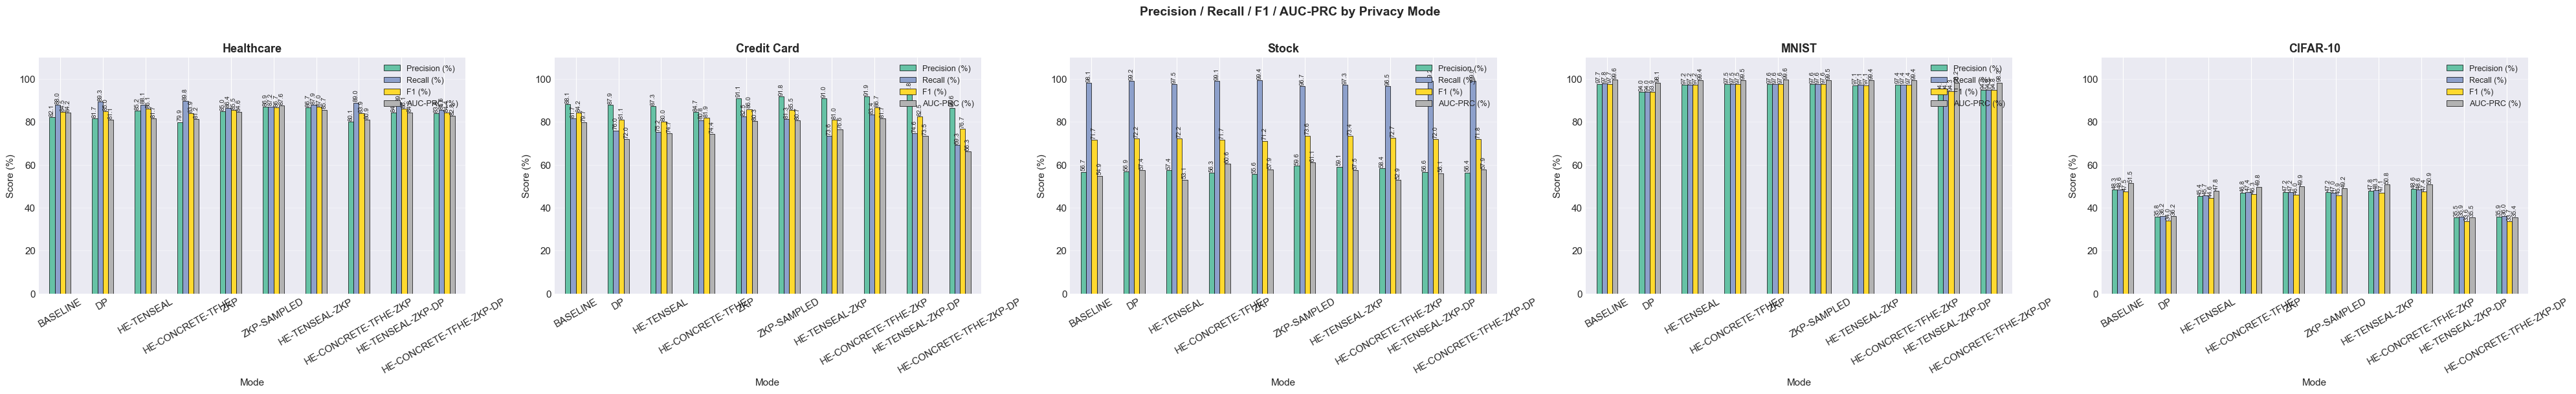

In [30]:
MQ_COLS = [
    'Mode',
    'Train Acc (%)', 'Val Acc (%)', 'Test Acc (%)',
    'Precision (%)', 'Recall (%)', 'F1 (%)', 'AUC-PRC (%)',
    'Train Loss', 'Val Loss', 'Test Loss', 'Threshold',
]

def show_quality(df, label):
    if df is None:
        print(f"⚠️  {label}: not available"); return
    cols = [c for c in MQ_COLS if c in df.columns]
    print("\n" + "="*130)
    print(f"🎯 {label} — MODEL QUALITY METRICS (mean across rounds)")
    print("="*130)
    acc_cols  = [c for c in ['Val Acc (%)', 'Test Acc (%)', 'F1 (%)', 'AUC-PRC (%)', 'Precision (%)', 'Recall (%)'] if c in cols]
    loss_cols = [c for c in ['Train Loss', 'Val Loss', 'Test Loss'] if c in cols]
    styled = df[cols].round(4).style \
        .background_gradient(subset=acc_cols,  cmap='RdYlGn', vmin=50, vmax=100) \
        .background_gradient(subset=loss_cols, cmap='RdYlGn_r', vmin=0, vmax=1)
    display(styled)

for label, df in ALL_DATASETS:
    show_quality(df, label)

# ── Bar chart: Precision / Recall / F1 / AUC-PRC across datasets ─────────────
metric_cols = ['Precision (%)', 'Recall (%)', 'F1 (%)', 'AUC-PRC (%)']

if ALL_DATASETS:
    n_datasets = len(ALL_DATASETS)
    fig, axes = plt.subplots(1, n_datasets, figsize=(8 * n_datasets, 6), sharey=False)
    if n_datasets == 1:
        axes = [axes]

    for ax, (label, df) in zip(axes, ALL_DATASETS):
        avail = [c for c in metric_cols if c in df.columns and df[c].sum() > 0]
        if not avail:
            ax.set_title(f"{label}\n(no metrics)"); continue
        plot_df = df.set_index('Mode')[avail]
        plot_df.plot(kind='bar', ax=ax, rot=30, colormap='Set2', edgecolor='black', linewidth=0.5)
        ax.set_title(f"{label}", fontsize=13, fontweight='bold')
        ax.set_xlabel('Mode', fontsize=11)
        ax.set_ylabel('Score (%)', fontsize=11)
        ax.set_ylim(0, 110)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(axis='y', alpha=0.4)
        for bar in ax.patches:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                        f'{h:.1f}', ha='center', va='bottom', fontsize=7, rotation=90)

    plt.suptitle('Precision / Recall / F1 / AUC-PRC by Privacy Mode', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


### 3.4 Resource Usage — Communication & Memory
Per-round communication sizes and peak memory consumption (client + server).


📡 Healthcare — RESOURCE USAGE (communication & memory)


,Mode,Clients,Rounds,Upload Mean (KB),Download Mean (KB),Upload Total (MB),Download Total (MB),Client Mem Mean (MB),Server Mem Mean (MB),Client Mem Peak (MB),Server Mem Peak (MB)
0,BASELINE,3,20,11.383000,11.383000,0.656000,0.656000,747.982000,744.777000,748.320000,744.969000
1,DP,3,20,11.383000,11.383000,0.656000,0.656000,748.074000,744.566000,748.379000,744.738000
2,HE-TENSEAL,3,20,657.831000,472.303000,37.902000,27.213000,849.075000,832.273000,851.297000,835.723000
3,HE-CONCRETE-TFHE,3,20,18241.538000,18241.540000,1068.840000,1068.840000,992.624000,1558.033000,1091.375000,1632.113000
4,ZKP,3,20,12.887000,11.383000,0.742000,0.656000,747.885000,745.258000,748.414000,745.508000
5,ZKP-SAMPLED,3,20,12.887000,11.383000,0.742000,0.656000,747.980000,745.361000,748.457000,745.594000
6,HE-TENSEAL-ZKP,3,20,659.375000,475.481000,38.635000,27.860000,850.224000,828.880000,852.098000,830.879000
7,HE-CONCRETE-TFHE-ZKP,3,20,18243.043000,18241.540000,1068.928000,1068.840000,995.108000,1551.338000,1098.973000,1660.391000
8,HE-TENSEAL-ZKP-DP,3,20,659.395000,475.376000,38.636000,27.854000,850.444000,830.055000,852.918000,832.488000
9,HE-CONCRETE-TFHE-ZKP-DP,3,20,18243.044000,18241.541000,1068.928000,1068.840000,993.110000,1581.882000,1094.367000,1650.367000



📡 Credit Card — RESOURCE USAGE (communication & memory)


,Mode,Clients,Rounds,Upload Mean (KB),Download Mean (KB),Upload Total (MB),Download Total (MB),Client Mem Mean (MB),Server Mem Mean (MB),Client Mem Peak (MB),Server Mem Peak (MB)
0,BASELINE,3,20,16.133000,16.133000,0.930000,0.930000,804.096000,804.597000,804.820000,806.273000
1,DP,3,20,16.133000,16.133000,0.930000,0.930000,805.592000,804.654000,806.230000,806.203000
2,HE-TENSEAL,3,20,657.933000,472.350000,37.908000,27.215000,904.554000,875.811000,906.969000,878.590000
3,HE-CONCRETE-TFHE,3,20,25853.349000,25853.349000,1514.845000,1514.845000,1121.047000,1928.104000,1234.688000,2050.668000
4,ZKP,3,20,17.637000,16.133000,1.016000,0.930000,805.479000,805.742000,806.266000,806.820000
5,ZKP-SAMPLED,3,20,17.637000,16.133000,1.016000,0.930000,805.108000,805.623000,806.480000,806.938000
6,HE-TENSEAL-ZKP,3,20,659.402000,475.454000,38.637000,27.859000,904.869000,877.541000,907.078000,879.129000
7,HE-CONCRETE-TFHE-ZKP,3,20,25854.855000,25853.349000,1514.933000,1514.845000,1103.877000,1944.142000,1267.832000,2035.090000
8,HE-TENSEAL-ZKP-DP,3,20,659.401000,475.385000,38.637000,27.855000,905.887000,876.778000,907.922000,878.414000
9,HE-CONCRETE-TFHE-ZKP-DP,3,20,25854.855000,25853.350000,1514.933000,1514.845000,1107.799000,1936.569000,1262.691000,2057.398000



📡 Stock — RESOURCE USAGE (communication & memory)


,Mode,Clients,Rounds,Upload Mean (KB),Download Mean (KB),Upload Total (MB),Download Total (MB),Client Mem Mean (MB),Server Mem Mean (MB),Client Mem Peak (MB),Server Mem Peak (MB)
0,BASELINE,3,20,11.383000,11.383000,0.656000,0.656000,749.732000,746.711000,749.895000,746.883000
1,DP,3,20,11.383000,11.383000,0.656000,0.656000,749.977000,747.075000,750.207000,747.254000
2,HE-TENSEAL,3,20,657.839000,472.280000,37.903000,27.211000,849.640000,829.188000,851.953000,831.852000
3,HE-CONCRETE-TFHE,3,20,18241.538000,18241.535000,1068.840000,1068.840000,991.613000,1536.330000,1093.547000,1644.465000
4,ZKP,3,20,12.887000,11.383000,0.742000,0.656000,749.952000,747.177000,750.176000,747.391000
5,ZKP-SAMPLED,3,20,12.887000,11.383000,0.742000,0.656000,750.130000,747.227000,750.469000,747.461000
6,HE-TENSEAL-ZKP,3,20,659.384000,475.325000,38.636000,27.851000,850.835000,830.229000,852.770000,832.062000
7,HE-CONCRETE-TFHE-ZKP,3,20,18243.045000,18241.535000,1068.928000,1068.840000,985.957000,1565.029000,1077.582000,1670.539000
8,HE-TENSEAL-ZKP-DP,3,20,659.402000,475.491000,38.637000,27.861000,851.389000,829.580000,853.859000,831.230000
9,HE-CONCRETE-TFHE-ZKP-DP,3,20,18243.042000,18241.537000,1068.928000,1068.840000,988.552000,1527.569000,1089.789000,1592.766000



📡 MNIST — RESOURCE USAGE (communication & memory)


,Mode,Clients,Rounds,Upload Mean (KB),Download Mean (KB),Upload Total (MB),Download Total (MB),Client Mem Mean (MB),Server Mem Mean (MB),Client Mem Peak (MB),Server Mem Peak (MB)
0,BASELINE,3,20,173.539000,173.539000,9.999000,9.999000,825.083000,823.473000,826.289000,824.801000
1,DP,3,20,173.539000,173.539000,9.999000,9.999000,825.427000,823.876000,826.324000,825.570000
2,HE-TENSEAL,3,20,161.318000,161.091000,9.295000,9.282000,912.183000,864.451000,913.133000,865.676000
3,HE-CONCRETE-TFHE,3,20,69.373000,84.958000,4.065000,4.978000,823.604000,804.698000,824.309000,805.434000
4,ZKP,3,20,180.199000,173.539000,10.383000,9.999000,825.572000,824.036000,826.660000,825.902000
5,ZKP-SAMPLED,3,20,180.199000,173.539000,10.383000,9.999000,825.509000,823.507000,826.199000,825.113000
6,HE-TENSEAL-ZKP,3,20,167.946000,161.029000,9.841000,9.435000,912.313000,864.431000,913.438000,865.367000
7,HE-CONCRETE-TFHE-ZKP,3,20,75.967000,84.733000,4.451000,4.965000,824.054000,804.587000,825.094000,805.336000
8,HE-TENSEAL-ZKP-DP,3,20,168.269000,161.251000,9.859000,9.448000,912.518000,864.970000,914.406000,866.578000
9,HE-CONCRETE-TFHE-ZKP-DP,3,20,79.508000,87.956000,4.659000,5.154000,824.768000,805.076000,825.801000,805.727000



📡 CIFAR-10 — RESOURCE USAGE (communication & memory)


,Mode,Clients,Rounds,Upload Mean (KB),Download Mean (KB),Upload Total (MB),Download Total (MB),Client Mem Mean (MB),Server Mem Mean (MB),Client Mem Peak (MB),Server Mem Peak (MB)
0,BASELINE,3,20,242.211000,242.211000,13.956000,13.956000,1082.508000,1088.612000,1083.117000,1090.488000
1,DP,3,20,242.211000,242.211000,13.956000,13.956000,1082.564000,1088.772000,1083.336000,1090.797000
2,HE-TENSEAL,3,20,224.986000,224.638000,12.963000,12.943000,1084.308000,1081.081000,1085.207000,1083.055000
3,HE-CONCRETE-TFHE,3,20,92.523000,115.023000,5.331000,6.627000,1081.561000,1073.801000,1081.934000,1075.062000
4,ZKP,3,20,250.590000,242.211000,14.438000,13.956000,1083.052000,1089.229000,1083.867000,1091.250000
5,ZKP-SAMPLED,3,20,250.590000,242.211000,14.438000,13.956000,1083.076000,1089.447000,1083.891000,1090.957000
6,HE-TENSEAL-ZKP,3,20,233.408000,224.687000,13.676000,13.165000,1085.117000,1081.300000,1086.422000,1083.043000
7,HE-CONCRETE-TFHE-ZKP,3,20,100.757000,114.595000,5.904000,6.715000,1080.917000,1073.644000,1082.191000,1074.695000
8,HE-TENSEAL-ZKP-DP,3,20,233.959000,225.046000,13.709000,13.186000,1084.824000,1080.541000,1085.836000,1082.766000
9,HE-CONCRETE-TFHE-ZKP-DP,3,20,111.355000,123.249000,6.525000,7.222000,1082.093000,1074.508000,1082.668000,1076.648000


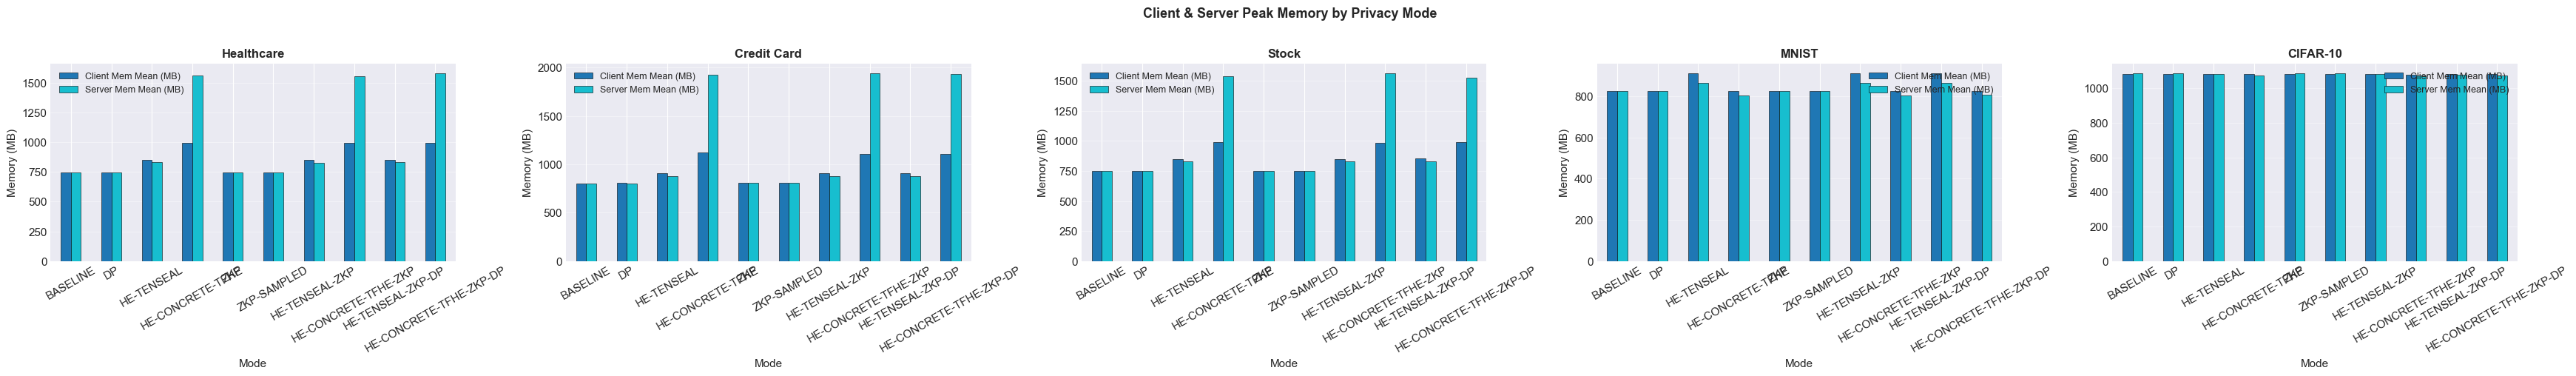

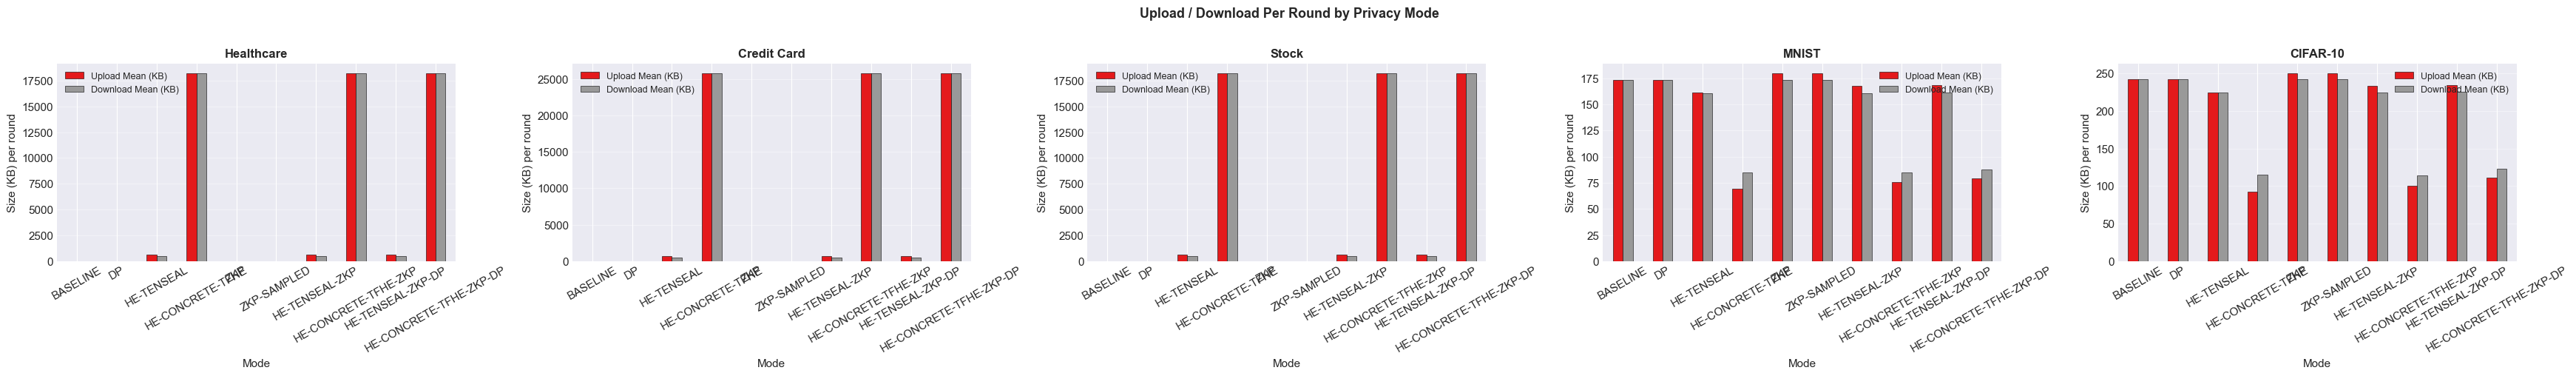

In [31]:
RES_COLS = [
    'Mode', 'Clients', 'Rounds',
    'Upload Mean (KB)', 'Download Mean (KB)',
    'Upload Total (MB)', 'Download Total (MB)',
    'Client Mem Mean (MB)', 'Server Mem Mean (MB)',
    'Client Mem Peak (MB)', 'Server Mem Peak (MB)',
]

def show_resources(df, label):
    if df is None:
        print(f"⚠️  {label}: not available"); return
    cols = [c for c in RES_COLS if c in df.columns]
    print("\n" + "="*130)
    print(f"📡 {label} — RESOURCE USAGE (communication & memory)")
    print("="*130)
    comm_cols = [c for c in ['Upload Mean (KB)', 'Download Mean (KB)', 'Upload Total (MB)', 'Download Total (MB)'] if c in cols]
    mem_cols  = [c for c in ['Client Mem Mean (MB)', 'Server Mem Mean (MB)', 'Client Mem Peak (MB)', 'Server Mem Peak (MB)'] if c in cols]
    display(df[cols].round(3).style
            .background_gradient(subset=comm_cols, cmap='Blues')
            .background_gradient(subset=mem_cols,  cmap='Oranges'))

for label, df in ALL_DATASETS:
    show_resources(df, label)

# ── Memory bar chart ─────────────────────────────────────────────────────────
if ALL_DATASETS:
    fig, axes = plt.subplots(1, len(ALL_DATASETS), figsize=(7 * len(ALL_DATASETS), 5), sharey=False)
    if len(ALL_DATASETS) == 1:
        axes = [axes]
    for ax, (label, df) in zip(axes, ALL_DATASETS):
        mem_avail = [c for c in ['Client Mem Mean (MB)', 'Server Mem Mean (MB)'] if c in df.columns]
        if not mem_avail:
            continue
        plot_df = df.set_index('Mode')[mem_avail]
        plot_df.plot(kind='bar', ax=ax, rot=30, colormap='tab10', edgecolor='black', linewidth=0.4)
        ax.set_title(f"{label}", fontsize=12, fontweight='bold')
        ax.set_ylabel('Memory (MB)')
        ax.set_xlabel('Mode')
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.4)
    plt.suptitle('Client & Server Peak Memory by Privacy Mode', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# ── Communication bar chart ───────────────────────────────────────────────────
if ALL_DATASETS:
    fig, axes = plt.subplots(1, len(ALL_DATASETS), figsize=(7 * len(ALL_DATASETS), 5), sharey=False)
    if len(ALL_DATASETS) == 1:
        axes = [axes]
    for ax, (label, df) in zip(axes, ALL_DATASETS):
        comm_avail = [c for c in ['Upload Mean (KB)', 'Download Mean (KB)'] if c in df.columns]
        if not comm_avail:
            continue
        plot_df = df.set_index('Mode')[comm_avail]
        plot_df.plot(kind='bar', ax=ax, rot=30, colormap='Set1', edgecolor='black', linewidth=0.4)
        ax.set_title(f"{label}", fontsize=12, fontweight='bold')
        ax.set_ylabel('Size (KB) per round')
        ax.set_xlabel('Mode')
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.4)
    plt.suptitle('Upload / Download Per Round by Privacy Mode', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


### 3.5 Full Detail Table — All Metrics Combined
Every extracted field from the benchmark report in one sortable view.

In [32]:
ALL_COLS_ORDER = [
    'Mode', 'Dataset', 'Clients', 'Rounds', 'Success',
    # accuracy
    'Train Acc (%)', 'Val Acc (%)', 'Test Acc (%)',
    'Precision (%)', 'Recall (%)', 'F1 (%)', 'AUC-PRC (%)',
    # loss
    'Train Loss', 'Val Loss', 'Test Loss', 'Threshold',
    # timing (mean per round)
    'Fit Time (s)', 'Eval Time (s)', 'Get Params (s)', 'Aggregate Time (s)',
    'Encrypt Time (s)', 'Decrypt Time (s)',
    'Proof Gen (s)', 'Proof Verify (s)', 'DP Noise (s)',
    'Crypto Per Round (s)', 'Crypto Overhead (s)', 'Training Time (s)', 'Total Time (s)',
    # communication
    'Upload Mean (KB)', 'Download Mean (KB)',
    'Upload Total (MB)', 'Download Total (MB)',
    # memory
    'Client Mem Mean (MB)', 'Server Mem Mean (MB)',
    'Client Mem Peak (MB)', 'Server Mem Peak (MB)',
]

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

for label, df in ALL_DATASETS:
    cols = [c for c in ALL_COLS_ORDER if c in df.columns]
    print("\n" + "="*150)
    print(f"📑 {label.upper()} — FULL DETAIL (all benchmark fields)")
    print("="*150)
    acc_cols  = [c for c in cols if '(%)' in c]
    loss_cols = [c for c in cols if 'Loss' in c]
    hi_cols   = [c for c in cols if c in ('Total Time (s)', 'Crypto Overhead (s)')]
    display(
        df[cols].round(4).style
        .background_gradient(subset=[c for c in acc_cols  if c in cols], cmap='RdYlGn', vmin=50, vmax=100)
        .background_gradient(subset=[c for c in loss_cols if c in cols], cmap='RdYlGn_r', vmin=0, vmax=1)
        .background_gradient(subset=[c for c in hi_cols   if c in cols], cmap='YlOrRd')
    )



📑 HEALTHCARE — FULL DETAIL (all benchmark fields)


,Mode,Dataset,Clients,Rounds,Success,Train Acc (%),Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),AUC-PRC (%),Train Loss,Val Loss,Test Loss,Threshold,Fit Time (s),Eval Time (s),Get Params (s),Aggregate Time (s),Encrypt Time (s),Decrypt Time (s),Proof Gen (s),Proof Verify (s),DP Noise (s),Crypto Per Round (s),Crypto Overhead (s),Training Time (s),Total Time (s),Upload Mean (KB),Download Mean (KB),Upload Total (MB),Download Total (MB),Client Mem Mean (MB),Server Mem Mean (MB),Client Mem Peak (MB),Server Mem Peak (MB)
0,BASELINE,Healthcare,3,20,True,83.735000,79.975300,81.907500,82.127400,88.031800,84.515400,84.224100,0.398300,0.458400,0.465000,0.503700,0.341000,0.001900,0.000000,0.000200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.711100,6.711100,11.382800,11.382800,0.655800,0.655800,747.981900,744.776600,748.320300,744.968800
1,DP,Healthcare,3,20,True,82.631800,80.406100,81.464100,81.656300,89.333000,84.967500,81.075400,0.413800,0.483700,0.467800,0.513700,0.412700,0.002500,0.000000,0.000200,0.000000,0.000000,0.000000,0.000000,0.000400,0.000400,0.007000,8.120000,8.127100,11.382800,11.382800,0.655800,0.655800,748.074200,744.566000,748.378900,744.738300
2,HE-TENSEAL,Healthcare,3,20,True,83.434000,79.812900,80.746300,85.191500,88.068900,86.138800,81.693900,0.398500,0.471600,0.459200,0.545800,0.320000,0.001100,0.037500,0.128000,0.042500,0.007500,0.000000,0.000000,0.000000,0.177200,3.543600,6.292600,9.836100,657.831300,472.303100,37.902400,27.212800,849.075100,832.273000,851.296900,835.722700
3,HE-CONCRETE-TFHE,Healthcare,3,20,True,72.090200,70.072900,68.344900,79.913100,89.844000,83.923500,81.177000,0.559800,0.577600,0.572600,0.536900,0.217600,0.001100,2.697900,3.243800,3.474200,1.041900,0.000000,0.000000,0.000000,7.759900,155.198800,4.351800,159.550600,18241.538200,18241.540100,1068.840100,1068.840200,992.624300,1558.033000,1091.375000,1632.113300
4,ZKP,Healthcare,3,20,True,83.626000,82.779000,82.772800,85.010900,86.381500,85.509700,84.586000,0.390200,0.465700,0.455000,0.557500,0.329000,0.001000,0.000000,0.000200,0.000000,0.000000,34.669600,0.048900,0.000000,34.150500,683.010800,6.474100,689.484900,12.886700,11.382800,0.742500,0.655800,747.885200,745.258200,748.414100,745.507800
5,ZKP-SAMPLED,Healthcare,3,20,True,83.951000,81.758500,81.973500,86.933100,87.164300,86.660100,87.584300,0.384300,0.455200,0.453000,0.555600,0.341300,0.001100,0.000000,0.000200,0.000000,0.000000,34.738200,0.048700,0.000000,34.201600,684.031400,6.715700,690.747000,12.886700,11.382800,0.742500,0.655800,747.980000,745.361300,748.457000,745.593800
6,HE-TENSEAL-ZKP,Healthcare,3,20,True,82.936200,80.833300,81.622000,86.685600,87.892200,87.022400,85.654000,0.396400,0.463800,0.462000,0.545300,0.320200,0.001100,14.778400,0.128700,0.051800,0.007300,35.080500,0.018100,0.000000,35.860800,717.215300,6.404500,723.619800,659.374800,475.481200,38.635200,27.860200,850.223500,828.880500,852.097700,830.878900
7,HE-CONCRETE-TFHE-ZKP,Healthcare,3,20,True,70.489100,68.170100,66.409700,80.137600,88.997300,83.908500,80.896000,0.556400,0.584200,0.592400,0.498900,0.212100,0.001100,18.471700,3.436400,3.682000,1.088300,36.436400,0.018600,0.000000,45.258000,905.160200,4.242900,909.403100,18243.043100,18241.540400,1068.928300,1068.840300,995.108500,1551.337500,1098.972700,1660.390600
8,HE-TENSEAL-ZKP-DP,Healthcare,3,20,True,83.143600,79.027800,79.841300,84.364600,89.153300,86.136600,84.327300,0.401200,0.480200,0.464000,0.575600,0.414600,0.001100,15.019400,0.129200,0.055900,0.007200,35.292200,0.018700,0.000400,36.081800,721.635800,8.291600,729.927400,659.395500,475.376300,38.636500,27.854100,850.443700,830.055300,852.918000,832.488300
9,HE-CONCRETE-TFHE-ZKP-DP,Healthcare,3,20,True,68.783000,66.392400,68.513600,83.940800,85.635800,84.366700,82.830700,0.562800,0.589500,0.583900,0.562800,0.347400,0.001100,17.969500,3.439300,3.703700,1.096100,36.498400,0.018900,0.000400,45.353900,907.078000,6.947100,914.025100,18243.043800,18241.541400,1068.928300,1068.840300,9


📑 CREDIT CARD — FULL DETAIL (all benchmark fields)


,Mode,Dataset,Clients,Rounds,Success,Train Acc (%),Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),AUC-PRC (%),Train Loss,Val Loss,Test Loss,Threshold,Fit Time (s),Eval Time (s),Get Params (s),Aggregate Time (s),Encrypt Time (s),Decrypt Time (s),Proof Gen (s),Proof Verify (s),DP Noise (s),Crypto Per Round (s),Crypto Overhead (s),Training Time (s),Total Time (s),Upload Mean (KB),Download Mean (KB),Upload Total (MB),Download Total (MB),Client Mem Mean (MB),Server Mem Mean (MB),Client Mem Peak (MB),Server Mem Peak (MB)
0,BASELINE,Credit Card,3,20,True,99.947400,99.946100,99.946000,88.107100,81.692300,84.202700,79.674800,0.002600,0.003200,0.003100,0.463700,69.366600,0.110100,0.000000,0.000300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1364.215500,1364.215500,16.132800,16.132800,0.929500,0.929500,804.095600,804.596900,804.820300,806.273400
1,DP,Credit Card,3,20,True,99.919100,99.915900,99.930000,87.918000,76.006400,81.114500,71.971900,0.007800,0.008900,0.007200,0.621300,77.745100,0.104600,0.000000,0.000300,0.000000,0.000000,0.000000,0.000000,0.000400,0.000400,0.008600,1528.993000,1529.001500,16.132800,16.132800,0.929500,0.929500,805.591900,804.653500,806.230500,806.203100
2,HE-TENSEAL,Credit Card,3,20,True,99.944700,99.939700,99.938900,87.328300,75.179500,80.029100,74.728400,0.002600,0.003300,0.003300,0.514500,63.955200,0.082500,0.059200,0.135900,0.052300,0.008100,0.000000,0.000000,0.000000,0.195300,3.906700,1257.786300,1261.693000,657.933200,472.349600,37.908300,27.215500,904.554400,875.810500,906.968800,878.589800
3,HE-CONCRETE-TFHE,Credit Card,3,20,True,99.925100,99.931700,99.936400,84.714300,80.846200,81.882500,74.403400,0.003300,0.003500,0.003300,0.278300,69.640800,0.086800,3.222300,3.825500,4.293000,1.191300,0.000000,0.000000,0.000000,9.309800,186.195000,1392.815600,1579.010700,25853.349400,25853.349200,1514.844700,1514.844700,1121.046900,1928.104100,1234.687500,2050.668000
4,ZKP,Credit Card,3,20,True,99.944700,99.945500,99.940800,91.098900,82.525600,85.953800,80.340600,0.002700,0.003300,0.003300,0.441500,63.831100,0.091100,0.000000,0.000200,0.000000,0.000000,54.650000,0.061700,0.000000,53.908700,1078.175000,1255.349400,2333.524400,17.636700,16.132800,1.016200,0.929500,805.478900,805.742200,806.265600,806.820300
5,ZKP-SAMPLED,Credit Card,3,20,True,99.942600,99.936600,99.939600,91.777800,81.307700,85.476100,80.707500,0.002700,0.003300,0.003300,0.435800,63.345600,0.087500,0.000000,0.000200,0.000000,0.000000,47.914500,0.061200,0.000000,47.174000,943.479700,1245.801800,2189.281500,17.636700,16.132800,1.016200,0.929500,805.108300,805.623000,806.480500,806.937500
6,HE-TENSEAL-ZKP,Credit Card,3,20,True,99.944700,99.944000,99.943700,91.000000,73.576900,81.018800,76.552200,0.002700,0.003200,0.003200,0.573200,65.160500,0.080100,20.789500,0.130300,0.069400,0.007600,48.040900,0.018300,0.000000,49.060700,981.214100,1303.210700,2284.424800,659.402000,475.453700,38.636800,27.858600,904.869500,877.541000,907.078100,879.128900
7,HE-CONCRETE-TFHE-ZKP,Credit Card,3,20,True,99.925400,99.933900,99.935300,91.904800,83.423100,86.676400,81.674600,0.003300,0.003500,0.003400,0.347800,72.344200,0.086600,24.564500,4.008500,4.730100,1.209100,50.361500,0.019300,0.000000,61.170700,1223.413900,1446.884700,2670.298600,25854.854700,25853.348700,1514.932900,1514.844600,1103.877000,1944.141600,1267.832000,2035.089800
8,HE-TENSEAL-ZKP-DP,Credit Card,3,20,True,99.920200,99.922800,99.918600,92.777800,74.576900,82.466600,73.505600,0.006900,0.008100,0.006500,0.591300,76.173500,0.083100,20.630000,0.130500,0.067500,0.007600,47.547900,0.018600,0.000400,48.570900,971.418500,1523.470900,2494.889300,659.400800,475.384900,38.636800,27.854600,905.887400,876.778100,907.921900,878.414100
9,HE-CONCRETE-TFHE-ZKP-DP,Credit Card,3,20,True,99.919400,99.924300,99.925900,86.569900,69.307700,76.733300,66.288000,0.007300,0.008100,0.006800,0.682300,84.345100,0.086400,24.268900,3.956300,4.607400,1.201000,49.805500,0.018700,0.000500,60.399400,1207.988000,1686


📑 STOCK — FULL DETAIL (all benchmark fields)


,Mode,Dataset,Clients,Rounds,Success,Train Acc (%),Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),AUC-PRC (%),Train Loss,Val Loss,Test Loss,Threshold,Fit Time (s),Eval Time (s),Get Params (s),Aggregate Time (s),Encrypt Time (s),Decrypt Time (s),Proof Gen (s),Proof Verify (s),DP Noise (s),Crypto Per Round (s),Crypto Overhead (s),Training Time (s),Total Time (s),Upload Mean (KB),Download Mean (KB),Upload Total (MB),Download Total (MB),Client Mem Mean (MB),Server Mem Mean (MB),Client Mem Peak (MB),Server Mem Peak (MB)
0,BASELINE,Stock,3,20,True,54.842700,53.019100,55.068500,56.742000,98.072800,71.748300,54.895400,0.686500,0.692400,0.688900,0.490100,0.855300,0.002700,0.000000,0.000200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.824400,16.824400,11.382800,11.382800,0.655800,0.655800,749.732500,746.711300,749.894500,746.882800
1,DP,Stock,3,20,True,54.211500,52.718900,52.656200,56.884900,99.151200,72.212800,57.363300,0.687000,0.694900,0.690600,0.462600,1.157500,0.002200,0.000000,0.000200,0.000000,0.000000,0.000000,0.000000,0.000300,0.000300,0.006400,22.768200,22.774700,11.382800,11.382800,0.655800,0.655800,749.976700,747.075400,750.207000,747.253900
2,HE-TENSEAL,Stock,3,20,True,55.323800,54.078400,55.489400,57.412100,97.502400,72.209100,53.120000,0.685200,0.696100,0.691900,0.480500,0.947400,0.002200,0.036700,0.130300,0.045600,0.007300,0.000000,0.000000,0.000000,0.182300,3.647000,18.632300,22.279300,657.838600,472.279600,37.902800,27.211400,849.640300,829.187500,851.953100,831.851600
3,HE-CONCRETE-TFHE,Stock,3,20,True,52.220100,55.555600,55.555600,56.322100,99.051400,71.745300,60.603100,0.691200,0.691200,0.689200,0.521000,0.875800,0.002200,2.691100,3.287300,3.566500,1.058000,0.000000,0.000000,0.000000,7.911900,158.237200,17.516300,175.753400,18241.537900,18241.535200,1068.840100,1068.840000,991.613300,1536.329900,1093.546900,1644.464800
4,ZKP,Stock,3,20,True,54.588900,51.359500,52.997700,55.588800,99.366100,71.216700,57.894400,0.686200,0.693900,0.689600,0.475700,1.101900,0.002300,0.000000,0.000200,0.000000,0.000000,33.754700,0.048700,0.000000,33.235300,664.705100,21.674800,686.379900,12.886700,11.382800,0.742500,0.655800,749.951900,747.177000,750.175800,747.390600
5,ZKP-SAMPLED,Stock,3,20,True,54.881000,52.930800,52.334100,59.636100,96.702100,73.597200,61.087400,0.686300,0.694300,0.690800,0.488800,0.994800,0.002300,0.000000,0.000200,0.000000,0.000000,34.682700,0.050600,0.000000,34.148900,682.978600,19.568400,702.547000,12.886700,11.382800,0.742500,0.655800,750.130300,747.227000,750.468800,747.460900
6,HE-TENSEAL-ZKP,Stock,3,20,True,55.127300,51.267400,55.671300,59.127800,97.340400,73.425000,57.480000,0.685300,0.695800,0.691000,0.485300,1.065900,0.002300,14.723900,0.128400,0.054700,0.006900,35.067400,0.018200,0.000000,35.849000,716.980500,21.318300,738.298800,659.383500,475.324900,38.635800,27.851100,850.834700,830.228900,852.769500,832.062500
7,HE-CONCRETE-TFHE-ZKP,Stock,3,20,True,52.233800,55.520800,55.555600,58.394600,96.545000,72.651700,52.863300,0.691200,0.691200,0.689200,0.520900,1.069700,0.002300,17.668400,3.421600,3.683400,1.099900,36.592000,0.018500,0.000000,45.413800,908.275800,21.394600,929.670400,18243.044500,18241.535500,1068.928400,1068.840000,985.957500,1565.029500,1077.582000,1670.539100
8,HE-TENSEAL-ZKP-DP,Stock,3,20,True,53.106900,53.020800,54.682500,56.570000,99.157800,71.987100,56.124600,0.688100,0.692800,0.690600,0.465100,1.415000,0.002200,15.109900,0.129300,0.052000,0.007300,35.497500,0.018200,0.000400,36.285900,725.718500,28.299100,754.017600,659.402400,475.490800,38.636900,27.860800,851.388500,829.580500,853.859400,831.230500
9,HE-CONCRETE-TFHE-ZKP-DP,Stock,3,20,True,52.775600,52.326400,56.065200,56.444800,99.039100,71.848000,57.857400,0.690600,0.692500,0.689200,0.504800,1.236900,0.002300,17.604100,3.382400,3.768200,1.107000,36.682500,0.019200,0.000400,45.557800,911.155600,24.737100,935.892700,18243.042200,18241.537000,1068.928300,1068.840100,988.551800,1527.568800,1089.789100,159


📑 MNIST — FULL DETAIL (all benchmark fields)


,Mode,Dataset,Clients,Rounds,Success,Train Acc (%),Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),AUC-PRC (%),Train Loss,Val Loss,Test Loss,Threshold,Fit Time (s),Eval Time (s),Get Params (s),Aggregate Time (s),Encrypt Time (s),Decrypt Time (s),Proof Gen (s),Proof Verify (s),DP Noise (s),Crypto Per Round (s),Crypto Overhead (s),Training Time (s),Total Time (s),Upload Mean (KB),Download Mean (KB),Upload Total (MB),Download Total (MB),Client Mem Mean (MB),Server Mem Mean (MB),Client Mem Peak (MB),Server Mem Peak (MB)
0,BASELINE,MNIST,3,20,True,97.992000,97.441900,97.766100,97.732300,97.753000,97.734200,99.572900,0.065200,0.085100,0.076300,0.500000,46.177400,0.334800,0.000000,0.000500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,908.164900,908.164900,173.539100,173.539100,9.998800,9.998800,825.083000,823.472700,826.289100,824.800800
1,DP,MNIST,3,20,True,94.099900,94.024800,93.946200,94.026000,93.960800,93.932900,98.056500,0.196800,0.197100,0.195500,0.500000,52.197800,0.354200,0.000000,0.000500,0.000000,0.000000,0.000000,0.000000,0.001200,0.001200,0.024000,1026.567900,1026.591900,173.539100,173.539100,9.998800,9.998800,825.426800,823.875800,826.324200,825.570300
2,HE-TENSEAL,MNIST,3,20,True,97.418500,97.053800,97.100800,97.182600,97.204600,97.178800,99.395400,0.083200,0.095900,0.093100,0.500000,48.897500,0.315200,0.011700,0.225400,0.011600,0.007400,0.000000,0.000000,0.000000,0.244100,4.881900,961.651300,966.533200,161.317600,161.091400,9.294700,9.281600,912.182900,864.451400,913.132800,865.675800
3,HE-CONCRETE-TFHE,MNIST,3,20,True,97.638800,97.264800,97.537500,97.543800,97.526900,97.522000,99.489300,0.078000,0.090500,0.078900,0.500000,50.761600,0.302700,1.113900,0.024000,1.387300,0.002800,0.000000,0.000000,0.000000,1.414200,28.283100,1015.231400,1043.514600,69.373100,84.958000,4.064800,4.978000,823.604400,804.697900,824.308600,805.433600
4,ZKP,MNIST,3,20,True,97.954000,97.419600,97.557000,97.644800,97.623400,97.620500,99.557300,0.066200,0.084500,0.077700,0.500000,50.568400,0.347800,0.000000,0.000400,0.000000,0.000000,529.645000,0.540700,0.000000,521.276600,10425.532700,994.520000,11420.052800,180.199200,173.539100,10.382600,9.998800,825.572300,824.035700,826.660200,825.902300
5,ZKP-SAMPLED,MNIST,3,20,True,97.778700,97.277200,97.572700,97.625100,97.598100,97.596400,99.499000,0.073100,0.091000,0.082500,0.500000,48.460900,0.335200,0.000000,0.000400,0.000000,0.000000,515.453100,0.540900,0.000000,507.315200,10146.304100,953.072500,11099.376600,180.199200,173.539100,10.382600,9.998800,825.509300,823.507200,826.199200,825.113300
6,HE-TENSEAL-ZKP,MNIST,3,20,True,97.472200,96.962100,97.117500,97.137300,97.142500,97.122000,99.408000,0.081900,0.099200,0.094800,0.500000,48.674400,0.301000,219.226700,0.222500,0.009500,0.006800,513.352100,0.093300,0.000000,522.095500,10441.909600,973.487600,11415.397300,167.945900,161.029300,9.840600,9.435300,912.312800,864.431100,913.437500,865.367200
7,HE-CONCRETE-TFHE-ZKP,MNIST,3,20,True,97.470400,97.103700,97.424400,97.418800,97.420700,97.395000,99.435200,0.082000,0.096500,0.083800,0.500000,48.117800,0.299200,217.109500,0.025700,1.352200,0.002600,506.283700,0.090100,0.000000,516.039500,10320.790200,962.355200,11283.145400,75.967400,84.733100,4.451200,4.964800,824.054400,804.587300,825.093800,805.335900
8,HE-TENSEAL-ZKP-DP,MNIST,3,20,True,93.730700,93.885900,93.919300,94.329200,94.305000,94.260100,98.224600,0.209600,0.200100,0.196000,0.500000,50.600900,0.297100,213.366700,0.222100,0.009800,0.006600,504.329400,0.091500,0.001200,512.912300,10258.246000,1012.017000,11270.263000,168.268700,161.250800,9.859500,9.448300,912.517500,864.970300,914.406200,866.578100
9,HE-CONCRETE-TFHE-ZKP-DP,MNIST,3,20,True,94.257000,94.213100,95.156600,94.821200,94.831100,94.789100,98.340000,0.193700,0.193300,0.164700,0.500000,51.612900,0.294300,218.385900,0.024700,1.333700,0.002700,513.673800,0.090400,0.001200,523.528500,10470.570400,1032.258100,11502.828500,79.508000,87.955900,4.658700,5.153700,824.7682


📑 CIFAR-10 — FULL DETAIL (all benchmark fields)


,Mode,Dataset,Clients,Rounds,Success,Train Acc (%),Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),AUC-PRC (%),Train Loss,Val Loss,Test Loss,Threshold,Fit Time (s),Eval Time (s),Get Params (s),Aggregate Time (s),Encrypt Time (s),Decrypt Time (s),Proof Gen (s),Proof Verify (s),DP Noise (s),Crypto Per Round (s),Crypto Overhead (s),Training Time (s),Total Time (s),Upload Mean (KB),Download Mean (KB),Upload Total (MB),Download Total (MB),Client Mem Mean (MB),Server Mem Mean (MB),Client Mem Peak (MB),Server Mem Peak (MB)
0,BASELINE,CIFAR-10,3,20,True,46.895100,47.133800,47.236700,48.320800,48.578400,47.510600,51.454100,1.470400,1.472000,1.472500,0.500000,23.515900,0.373400,0.000000,0.000500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,462.490900,462.490900,242.210900,242.210900,13.955500,13.955500,1082.508300,1088.611500,1083.117200,1090.488300
1,DP,CIFAR-10,3,20,True,35.842300,35.817100,36.588100,35.792000,36.224800,34.040300,36.167800,1.752200,1.766900,1.737400,0.500000,26.154300,0.404600,0.000000,0.000600,0.000000,0.000000,0.000000,0.000000,0.003800,0.003700,0.074300,514.380300,514.454600,242.210900,242.210900,13.955500,13.955500,1082.563600,1088.772500,1083.335900,1090.796900
2,HE-TENSEAL,CIFAR-10,3,20,True,45.869000,45.180100,46.457100,45.375300,45.727400,44.560100,47.840800,1.504300,1.528700,1.494200,0.500000,24.028100,0.339700,0.014000,0.233500,0.016700,0.010900,0.000000,0.000000,0.000000,0.260700,5.213700,472.553200,477.766900,224.985900,224.637800,12.963100,12.943000,1084.307800,1081.080900,1085.207000,1083.054700
3,HE-CONCRETE-TFHE,CIFAR-10,3,20,True,47.883500,47.417700,47.655300,46.844100,47.403800,46.314000,49.806000,1.444100,1.468800,1.454500,0.500000,24.364200,0.343400,1.198300,0.034100,1.409600,0.006000,0.000000,0.000000,0.000000,1.426100,28.521600,479.162900,507.684400,92.523100,115.023400,5.330900,6.627300,1081.561300,1073.801200,1081.933600,1075.062500
4,ZKP,CIFAR-10,3,20,True,47.612200,46.924000,47.836100,47.205800,47.220200,45.954400,49.938300,1.450900,1.480500,1.451800,0.500000,25.420700,0.428700,0.000000,0.000500,0.000000,0.000000,753.041200,0.760100,0.000000,741.125600,14822.512800,499.950500,15322.463400,250.589800,242.210900,14.438300,13.955500,1083.051600,1089.229500,1083.867200,1091.250000
5,ZKP-SAMPLED,CIFAR-10,3,20,True,46.925900,46.427300,47.743900,47.232200,46.978200,45.869900,49.157900,1.468600,1.498400,1.466200,0.500000,25.520600,0.425200,0.000000,0.000500,0.000000,0.000000,746.078100,0.757700,0.000000,734.251700,14685.033600,501.914900,15186.948500,250.589800,242.210900,14.438300,13.955500,1083.076200,1089.447100,1083.890600,1090.957000
6,HE-TENSEAL-ZKP,CIFAR-10,3,20,True,47.154400,47.095100,49.847200,47.838000,48.260800,47.103200,50.841000,1.462800,1.478100,1.410600,0.500000,25.693400,0.342300,316.598000,0.228900,0.014100,0.012000,743.058200,0.120100,0.000000,755.582700,15111.654900,513.868600,15625.523500,233.408400,224.687000,13.676300,13.165300,1085.116700,1081.300200,1086.421900,1083.043000
7,HE-CONCRETE-TFHE-ZKP,CIFAR-10,3,20,True,47.634600,47.002800,48.590900,48.619200,48.559700,47.442200,50.937900,1.447700,1.477600,1.446700,0.500000,24.515800,0.352900,317.112000,0.034900,1.367400,0.006000,730.600300,0.118600,0.000000,744.085500,14881.710100,490.316700,15372.026800,100.757500,114.595200,5.903800,6.714600,1080.917100,1073.643800,1082.191400,1074.695300
8,HE-TENSEAL-ZKP-DP,CIFAR-10,3,20,True,34.578700,34.568600,36.222500,35.522100,35.893800,33.634300,35.459200,1.769100,1.786700,1.756100,0.500000,27.945900,0.348200,311.670100,0.229600,0.014800,0.012500,751.830800,0.125800,0.004000,764.506800,15290.135300,558.919000,15849.054300,233.959400,225.046500,13.708600,13.186300,1084.823700,1080.541200,1085.835900,1082.765600
9,HE-CONCRETE-TFHE-ZKP-DP,CIFAR-10,3,20,True,34.909400,34.637400,34.570600,35.880600,35.970400,33.675000,35.376900,1.789300,1.804900,1.814600,0.500000,28.909100,0.336900,320.861900,0.034800,1.393800,0.006500,759.236700,0.119600,0.004100,773.203600,15464.07

## 4. Accuracy Comparison Visualizations

### 4.1 Accuracy Bar Chart (Side-by-Side)

In [33]:
# Accuracy bar charts -- Train Acc and Val Acc, one subplot per available dataset
n = len(ALL_DATASETS)
if n == 0:
    print("No datasets available.")
else:
    titles = [lbl for lbl, _ in ALL_DATASETS]
    fig = make_subplots(rows=1, cols=n, subplot_titles=titles)

    # Dynamic colors so no dataset is dropped when n > 3
    base_colors = px.colors.qualitative.Safe
    train_colors = [base_colors[i % len(base_colors)] for i in range(n)]
    val_colors = [px.colors.qualitative.Pastel[i % len(px.colors.qualitative.Pastel)] for i in range(n)]

    for col_idx, (label, df) in enumerate(ALL_DATASETS, start=1):
        d = df.sort_values('Val Acc (%)', ascending=False)
        show_legend = (col_idx == 1)
        fig.add_trace(
            go.Bar(
                x=d['Mode'], y=d['Train Acc (%)'], name='Train Acc',
                marker_color=train_colors[col_idx - 1],
                text=d['Train Acc (%)'].round(1),
                textposition='outside', showlegend=show_legend
            ),
            row=1, col=col_idx
        )
        fig.add_trace(
            go.Bar(
                x=d['Mode'], y=d['Val Acc (%)'], name='Val Acc',
                marker_color=val_colors[col_idx - 1],
                text=d['Val Acc (%)'].round(1),
                textposition='outside', showlegend=show_legend
            ),
            row=1, col=col_idx
        )
        fig.update_yaxes(title_text='Accuracy (%)', range=[0, 110], row=1, col=col_idx)
        fig.update_xaxes(title_text='Privacy Mode', row=1, col=col_idx)

    fig.update_layout(
        title_text='<b>Training vs Validation Accuracy by Privacy Mode</b>',
        height=500, barmode='group', showlegend=True,
        template='plotly_white'
    )
    fig.show()

    # -- AUC-PRC bar chart (primary metric for imbalanced datasets) ------------
    if any('AUC-PRC (%)' in df.columns and df['AUC-PRC (%)'].sum() > 0
           for _, df in ALL_DATASETS):
        fig2 = make_subplots(rows=1, cols=n, subplot_titles=titles)
        prc_colors = [px.colors.qualitative.Bold[i % len(px.colors.qualitative.Bold)] for i in range(n)]

        for col_idx, (label, df) in enumerate(ALL_DATASETS, start=1):
            if 'AUC-PRC (%)' not in df.columns:
                continue
            d = df.sort_values('AUC-PRC (%)', ascending=False)
            fig2.add_trace(
                go.Bar(
                    x=d['Mode'], y=d['AUC-PRC (%)'], name=label,
                    marker_color=prc_colors[col_idx - 1],
                    text=d['AUC-PRC (%)'].round(2), textposition='outside',
                    showlegend=True
                ),
                row=1, col=col_idx
            )
            fig2.update_yaxes(title_text='AUC-PRC (%)', row=1, col=col_idx)
        fig2.update_layout(
            title_text='<b>AUC-PRC by Privacy Mode</b> (primary metric for imbalanced data)',
            height=450, template='plotly_white'
        )
        fig2.show()


### 4.2 Accuracy Heatmap

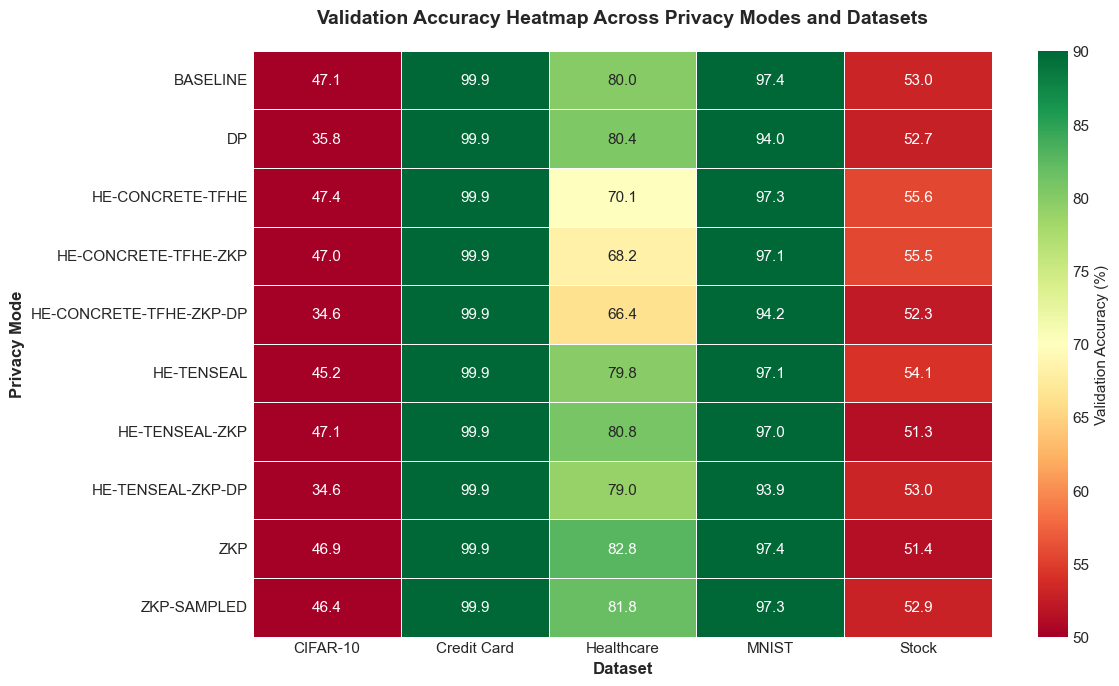


Key Insights:
- CIFAR-10 best mode: HE-CONCRETE-TFHE (47.4%)
- Credit Card best mode: BASELINE (99.9%)
- Healthcare best mode: ZKP (82.8%)
- MNIST best mode: BASELINE (97.4%)
- Stock best mode: HE-CONCRETE-TFHE (55.6%)
- Average accuracy loss vs baseline: 1.78%


In [34]:
# Create accuracy matrix for heatmap
accuracy_matrix = df_combined.pivot_table(
    index='Mode',
    columns='Dataset',
    values='Val Acc (%)',
    aggfunc='first'
)

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    accuracy_matrix,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=70,
    vmin=50,
    vmax=90,
    cbar_kws={'label': 'Validation Accuracy (%)'},
    linewidths=0.5,
    ax=ax
)

plt.title('Validation Accuracy Heatmap Across Privacy Modes and Datasets',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Dataset', fontsize=12, fontweight='bold')
plt.ylabel('Privacy Mode', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Insights:")
for dataset_label in accuracy_matrix.columns:
    best_mode = accuracy_matrix[dataset_label].idxmax()
    best_val = accuracy_matrix[dataset_label].max()
    print(f"- {dataset_label} best mode: {best_mode} ({best_val:.1f}%)")

baseline_vals = df_combined[df_combined['Mode'] == 'BASELINE']['Val Acc (%)']
non_baseline_vals = df_combined[df_combined['Mode'] != 'BASELINE']['Val Acc (%)']
if not baseline_vals.empty and not non_baseline_vals.empty:
    avg_delta = baseline_vals.mean() - non_baseline_vals.mean()
    print(f"- Average accuracy loss vs baseline: {avg_delta:.2f}%")


## 5. Performance Analysis

### 5.1 Execution Time Breakdown

In [35]:
# Stacked bar: training time vs cryptographic overhead (wall-clock, per run)
# Training Time = Total Time − Crypto Overhead (both correctly parallelism-adjusted)
# This shows how much of the total wall-clock is due to privacy operations.

n = len(ALL_DATASETS)
if n == 0:
    print("No datasets available.")
else:
    titles = [lbl for lbl, _ in ALL_DATASETS]
    fig = make_subplots(rows=1, cols=n, subplot_titles=titles)

    for col_idx, (label, df) in enumerate(ALL_DATASETS, start=1):
        d = df.copy()
        # Clamp to avoid negative training time if rounding
        d['Training Time (s)'] = d['Training Time (s)'].clip(lower=0)

        show_legend = (col_idx == 1)
        fig.add_trace(
            go.Bar(x=d['Mode'], y=d['Training Time (s)'],
                   name='Training Time', marker_color='steelblue',
                   showlegend=show_legend),
            row=1, col=col_idx
        )
        fig.add_trace(
            go.Bar(x=d['Mode'], y=d['Crypto Overhead (s)'],
                   name='Crypto Overhead', marker_color='orangered',
                   showlegend=show_legend),
            row=1, col=col_idx
        )
        fig.update_yaxes(title_text="Wall-clock time (s)", row=1, col=col_idx)
        fig.update_xaxes(title_text="Privacy Mode", row=1, col=col_idx)

    fig.update_layout(
        title_text='<b>Wall-clock Time: Training vs Cryptographic Overhead</b>',
        height=500,
        barmode='stack',
        template='plotly_white',
    )
    fig.show()

    # Print summary
    print("\n📊 Crypto overhead as % of total wall-clock time:")
    for label, df in ALL_DATASETS:
        print(f"\n  {label}:")
        for _, row in df.iterrows():
            pct = 100 * row['Crypto Overhead (s)'] / row['Total Time (s)'] if row['Total Time (s)'] > 0 else 0
            print(f"    {row['Mode']:<22}: {row['Total Time (s)']:6.1f}s total  |  {row['Crypto Overhead (s)']:6.2f}s crypto  ({pct:.1f}%)")



📊 Crypto overhead as % of total wall-clock time:

  Healthcare:
    BASELINE              :    6.7s total  |    0.00s crypto  (0.0%)
    DP                    :    8.1s total  |    0.01s crypto  (0.1%)
    HE-TENSEAL            :    9.8s total  |    3.54s crypto  (36.0%)
    HE-CONCRETE-TFHE      :  159.6s total  |  155.20s crypto  (97.3%)
    ZKP                   :  689.5s total  |  683.01s crypto  (99.1%)
    ZKP-SAMPLED           :  690.7s total  |  684.03s crypto  (99.0%)
    HE-TENSEAL-ZKP        :  723.6s total  |  717.22s crypto  (99.1%)
    HE-CONCRETE-TFHE-ZKP  :  909.4s total  |  905.16s crypto  (99.5%)
    HE-TENSEAL-ZKP-DP     :  729.9s total  |  721.64s crypto  (98.9%)
    HE-CONCRETE-TFHE-ZKP-DP:  914.0s total  |  907.08s crypto  (99.2%)

  Credit Card:
    BASELINE              : 1364.2s total  |    0.00s crypto  (0.0%)
    DP                    : 1529.0s total  |    0.01s crypto  (0.0%)
    HE-TENSEAL            : 1261.7s total  |    3.91s crypto  (0.3%)
    HE-CONCRE

### 5.2 Overhead Ratio Analysis

In [36]:
# Overhead ratio vs baseline for all datasets
fig = go.Figure()

palette = px.colors.qualitative.Dark24
dataset_colors = [palette[i % len(palette)] for i in range(len(ALL_DATASETS))]

dfs_with_overhead = []
for i, (label, df) in enumerate(ALL_DATASETS):
    baseline_rows = df[df['Mode'] == 'BASELINE']
    if baseline_rows.empty:
        print(f"⚠️  {label}: no baseline row, skipping overhead chart")
        continue
    baseline_time = baseline_rows['Total Time (s)'].values[0]
    d = df.copy()
    d['Overhead Ratio'] = d['Total Time (s)'] / baseline_time
    d['Overhead %'] = (d['Overhead Ratio'] - 1) * 100
    d['_label'] = label
    d['_color'] = dataset_colors[i]
    dfs_with_overhead.append((label, d, dataset_colors[i]))

    fig.add_trace(go.Bar(
        name=label,
        x=d['Mode'],
        y=d['Overhead Ratio'],
        text=d['Overhead Ratio'].round(2),
        textposition='outside',
        marker_color=dataset_colors[i]
    ))

fig.add_hline(y=1.0, line_dash='dash', line_color='red',
              annotation_text='Baseline (1.0x)', annotation_position='right')

fig.update_layout(
    title='<b>Performance Overhead Ratio vs Baseline</b>',
    xaxis_title='Privacy Mode',
    yaxis_title='Overhead Ratio (x)',
    barmode='group',
    height=500,
    template='plotly_white',
    showlegend=True
)
fig.show()

# Print overhead statistics
print("\nOverhead Statistics (wall-clock time):")
for label, d, _ in dfs_with_overhead:
    print(f"\n  {label}:")
    baseline_time = d[d['Mode'] == 'BASELINE']['Total Time (s)'].values[0]
    print(f"    Baseline: {baseline_time:.1f}s")
    for _, row in d[d['Mode'] != 'BASELINE'].iterrows():
        print(f"    {row['Mode']:<25}: {row['Overhead Ratio']:.2f}x ({row['Overhead %']:+.1f}%)")



Overhead Statistics (wall-clock time):

  Healthcare:
    Baseline: 6.7s
    DP                       : 1.21x (+21.1%)
    HE-TENSEAL               : 1.47x (+46.6%)
    HE-CONCRETE-TFHE         : 23.77x (+2277.4%)
    ZKP                      : 102.74x (+10173.7%)
    ZKP-SAMPLED              : 102.93x (+10192.5%)
    HE-TENSEAL-ZKP           : 107.82x (+10682.4%)
    HE-CONCRETE-TFHE-ZKP     : 135.51x (+13450.6%)
    HE-TENSEAL-ZKP-DP        : 108.76x (+10776.3%)
    HE-CONCRETE-TFHE-ZKP-DP  : 136.20x (+13519.5%)

  Credit Card:
    Baseline: 1364.2s
    DP                       : 1.12x (+12.1%)
    HE-TENSEAL               : 0.92x (-7.5%)
    HE-CONCRETE-TFHE         : 1.16x (+15.7%)
    ZKP                      : 1.71x (+71.1%)
    ZKP-SAMPLED              : 1.60x (+60.5%)
    HE-TENSEAL-ZKP           : 1.67x (+67.5%)
    HE-CONCRETE-TFHE-ZKP     : 1.96x (+95.7%)
    HE-TENSEAL-ZKP-DP        : 1.83x (+82.9%)
    HE-CONCRETE-TFHE-ZKP-DP  : 2.12x (+112.2%)

  Stock:
    Baseline: 16.

### 5.3 Memory Usage Comparison

In [37]:
# Memory usage comparison -- client vs server for all datasets
n = len(ALL_DATASETS)
if n == 0:
    print("No datasets available.")
else:
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Client Peak Memory', 'Server Peak Memory')
    )

    palette = px.colors.qualitative.Dark24
    dataset_colors = [palette[i % len(palette)] for i in range(n)]

    for i, (label, df) in enumerate(ALL_DATASETS):
        color = dataset_colors[i]
        fig.add_trace(
            go.Bar(
                x=df['Mode'], y=df['Client Mem Mean (MB)'],
                name=label, marker_color=color, opacity=0.75
            ),
            row=1, col=1
        )
        fig.add_trace(
            go.Bar(
                x=df['Mode'], y=df['Server Mem Mean (MB)'],
                name=label, marker_color=color, opacity=0.75, showlegend=False
            ),
            row=1, col=2
        )

    fig.update_layout(
        title_text='<b>Memory Usage Across Privacy Modes</b>',
        height=500, barmode='group', template='plotly_white'
    )
    fig.update_yaxes(title_text='Memory (MB)', row=1, col=1)
    fig.update_yaxes(title_text='Memory (MB)', row=1, col=2)
    fig.update_xaxes(title_text='Privacy Mode', row=1, col=1)
    fig.update_xaxes(title_text='Privacy Mode', row=1, col=2)
    fig.show()


## 6. Privacy-Performance Trade-off Analysis

### 6.1 Scatter Plot: Accuracy vs Performance

In [38]:
# Create scatter plot for privacy-performance trade-off
fig = px.scatter(
    df_combined,
    x='Total Time (s)',
    y='Val Acc (%)',
    color='Mode',
    symbol='Dataset',
    size='Crypto Overhead (s)',
    hover_data=['Train Acc (%)', 'Fit Time (s)', 'Upload Mean (KB)'],
    title='<b>Privacy-Performance Trade-off: Accuracy vs Execution Time</b>',
    labels={
        'Total Time (s)': 'Total Execution Time (seconds)',
        'Val Acc (%)': 'Validation Accuracy (%)'
    },
    template='plotly_white',
    height=600,
    size_max=30
)

# Add quadrant lines
avg_time = df_combined['Total Time (s)'].mean()
avg_acc = df_combined['Val Acc (%)'].mean()

fig.add_vline(x=avg_time, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_hline(y=avg_acc, line_dash="dash", line_color="gray", opacity=0.5)

# Add annotations for ideal region
fig.add_annotation(
    x=20, y=85,
    text="<b>IDEAL</b><br>(High Acc, Low Time)",
    showarrow=False,
    font=dict(size=12, color="green"),
    bgcolor="lightgreen",
    opacity=0.3
)

fig.update_layout(
    legend=dict(
        orientation="v",
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99
    )
)

fig.show()

### 6.2 Pareto Frontier Analysis

In [39]:
def calculate_pareto_scores(df):
    """
    Calculate normalized privacy, accuracy, and performance scores.

    Privacy ordering (weakest -> strongest):
      baseline(0) < dp(4) < zkp/zkp_sampled(5) < he_tenseal(7) < he_concrete_tfhe(8)
      < he_tenseal_zkp(9) < he_concrete_tfhe_zkp(9.5) < he_tenseal_zkp_dp(9.75)
      < he_concrete_tfhe_zkp_dp(10)

    Rationale:
    - DP: formal epsilon-delta guarantee, but aggregator still sees noisy gradients
    - ZKP: integrity verification (no byzantine attacks), server still sees gradients
    - HE-TenSEAL: encrypted aggregation (confidentiality)
    - HE-Concrete-TFHE: exact FHE confidentiality with higher cost
    - Hybrids: HE confidentiality + ZKP integrity + optional DP guarantee
    """
    df = df.copy()

    PRIVACY_SCORES = {
        'BASELINE':                    0.0,
        'DP':                          4.0,
        'ZKP':                         5.0,
        'ZKP-SAMPLED':                 5.0,
        'HE-TENSEAL':                  7.0,
        'HE-CONCRETE-TFHE':            8.0,
        'HE-TENSEAL-ZKP':              9.0,
        'HE-CONCRETE-TFHE-ZKP':        9.5,
        'HE-TENSEAL-ZKP-DP':           9.75,
        'HE-CONCRETE-TFHE-ZKP-DP':     10.0,
    }
    df['Privacy Score'] = df['Mode'].map(PRIVACY_SCORES).fillna(0)

    # Primary accuracy metric: AUC-PRC if available and non-zero, else Val Acc
    use_auprc = 'AUC-PRC (%)' in df.columns and df['AUC-PRC (%)'].sum() > 0
    acc_col = 'AUC-PRC (%)' if use_auprc else 'Val Acc (%)'
    df['Accuracy Score'] = df[acc_col] / 100

    # Performance score (inverse of time overhead vs baseline)
    max_time = df['Total Time (s)'].max()
    df['Performance Score'] = 1 - (df['Total Time (s)'] / max_time)

    # Communication efficiency (inverse log scale -- HE upload is much larger)
    upload = df['Upload Mean (KB)'].replace(0, 0.001)
    df['Comm Score'] = 1 - (upload.apply(lambda x: np.log1p(x)) / np.log1p(upload.max() + 1))

    # Memory efficiency
    max_mem = df['Client Mem Mean (MB)'].max()
    df['Mem Score'] = 1 - (df['Client Mem Mean (MB)'] / max_mem) if max_mem > 0 else 1.0

    # Combined score (weighted)
    df['Combined Score'] = (
        0.35 * df['Accuracy Score'] +
        0.25 * df['Performance Score'] +
        0.25 * (df['Privacy Score'] / 10) +
        0.08 * df['Comm Score'] +
        0.07 * df['Mem Score']
    )
    return df, acc_col

# -- Pareto scores for all datasets -------------------------------------------
pareto_dfs = []
for label, df in ALL_DATASETS:
    scored, acc_col = calculate_pareto_scores(df)
    scored['_dataset'] = label
    pareto_dfs.append((label, scored, acc_col))

# -- Radar chart for the primary dataset (use first available) ----------------
if pareto_dfs:
    label0, df0, acc_col0 = pareto_dfs[0]
    fig = go.Figure()
    categories = ['Privacy', 'Accuracy', 'Performance', 'Comm Efficiency', 'Mem Efficiency']

    for _, row in df0.iterrows():
        values = [
            row['Privacy Score'] / 10,
            row['Accuracy Score'],
            row['Performance Score'],
            row['Comm Score'],
            row['Mem Score'],
        ]
        fig.add_trace(go.Scatterpolar(
            r=values + [values[0]],
            theta=categories + [categories[0]],
            name=row['Mode'],
            fill='toself',
            opacity=0.55
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        showlegend=True,
        title=f'<b>Multi-Dimensional Comparison ({label0})</b><br>'
              f'<sub>Accuracy={acc_col0} | Privacy scale: baseline=0, HE+ZKP+DP=10</sub>',
        height=600,
        template='plotly_white'
    )
    fig.show()

# -- Combined score table for all datasets ------------------------------------
for label, df, acc_col in pareto_dfs:
    top = df.nlargest(3, 'Combined Score')[
        ['Mode', 'Combined Score', 'Privacy Score', 'Accuracy Score', 'Performance Score', 'Comm Score']
    ]
    print(f"\nTop 3 Modes -- {label} (primary metric: {acc_col}):")
    display(top.round(3))



Top 3 Modes -- Healthcare (primary metric: AUC-PRC (%)):


,Mode,Combined Score,Privacy Score,Accuracy Score,Performance Score,Comm Score
2,HE-TENSEAL,0.7460,7.0000,0.8170,0.9890,0.3380
1,DP,0.7080,4.0000,0.8110,0.9910,0.7440
3,HE-CONCRETE-TFHE,0.6910,8.0000,0.8120,0.8250,0.0000



Top 3 Modes -- Credit Card (primary metric: AUC-PRC (%)):


,Mode,Combined Score,Privacy Score,Accuracy Score,Performance Score,Comm Score
2,HE-TENSEAL,0.6200,7.0000,0.7470,0.5640,0.3610
6,HE-TENSEAL-ZKP,0.5880,9.0000,0.7660,0.2110,0.3610
8,HE-TENSEAL-ZKP-DP,0.5780,9.7500,0.7350,0.1380,0.3610



Top 3 Modes -- Stock (primary metric: AUC-PRC (%)):


,Mode,Combined Score,Privacy Score,Accuracy Score,Performance Score,Comm Score
2,HE-TENSEAL,0.6420,7.0000,0.5310,0.9760,0.3380
1,DP,0.6210,4.0000,0.5740,0.9760,0.7440
3,HE-CONCRETE-TFHE,0.6150,8.0000,0.6060,0.8120,0.0000



Top 3 Modes -- MNIST (primary metric: AUC-PRC (%)):


,Mode,Combined Score,Privacy Score,Accuracy Score,Performance Score,Comm Score
3,HE-CONCRETE-TFHE,0.7970,8.0000,0.9950,0.9090,0.1830
2,HE-TENSEAL,0.7540,7.0000,0.9940,0.9160,0.0220
1,DP,0.6780,4.0000,0.9810,0.9110,0.0080



Top 3 Modes -- CIFAR-10 (primary metric: AUC-PRC (%)):


,Mode,Combined Score,Privacy Score,Accuracy Score,Performance Score,Comm Score
3,HE-CONCRETE-TFHE,0.6310,8.0000,0.4980,0.9680,0.1800
2,HE-TENSEAL,0.5870,7.0000,0.4780,0.9700,0.0200
1,DP,0.4690,4.0000,0.3620,0.9680,0.0070


## 7. Comprehensive Comparison Table

In [40]:
# Create comprehensive comparison table for all available datasets
COMP_COLS = [
    'Mode', 'Train Acc (%)', 'Val Acc (%)', 'F1 (%)', 'AUC-PRC (%)',
    'Fit Time (s)', 'Crypto Per Round (s)', 'Crypto Overhead (s)', 'Total Time (s)',
    'Upload Mean (KB)', 'Download Mean (KB)',
    'Client Mem Mean (MB)', 'Server Mem Mean (MB)'
]

for label, df in ALL_DATASETS:
    cols = [c for c in COMP_COLS if c in df.columns]
    numeric = df[cols].select_dtypes(include=[np.number]).columns.tolist()
    rounded = df[cols].copy()
    rounded[numeric] = rounded[numeric].round(3)

    # Gradient ranges depend on dataset characteristics
    acc_max = rounded['Val Acc (%)'].max() if 'Val Acc (%)' in cols else 100
    acc_min = max(acc_max - 10, 0)

    print("\n" + "="*130)
    print(f"📊 {label.upper()} — COMPREHENSIVE COMPARISON TABLE")
    print("="*130)
    styled = rounded.style
    if 'Val Acc (%)' in cols:
        styled = styled.background_gradient(subset=['Val Acc (%)'], cmap='RdYlGn',
                                            vmin=acc_min, vmax=acc_max)
    if 'AUC-PRC (%)' in cols and df['AUC-PRC (%)'].sum() > 0:
        auprc_max = rounded['AUC-PRC (%)'].max()
        styled = styled.background_gradient(subset=['AUC-PRC (%)'], cmap='Blues',
                                            vmin=auprc_max - 15, vmax=auprc_max)
    if 'Total Time (s)' in cols:
        styled = styled.background_gradient(subset=['Total Time (s)'], cmap='RdYlGn_r',
                                            vmin=0, vmax=df['Total Time (s)'].max())
    if 'Crypto Overhead (s)' in cols:
        styled = styled.background_gradient(subset=['Crypto Overhead (s)'], cmap='YlOrRd',
                                            vmin=0, vmax=df['Crypto Overhead (s)'].max())
    display(styled)



📊 HEALTHCARE — COMPREHENSIVE COMPARISON TABLE


,Mode,Train Acc (%),Val Acc (%),F1 (%),AUC-PRC (%),Fit Time (s),Crypto Per Round (s),Crypto Overhead (s),Total Time (s),Upload Mean (KB),Download Mean (KB),Client Mem Mean (MB),Server Mem Mean (MB)
0,BASELINE,83.735000,79.975000,84.515000,84.224000,0.341000,0.000000,0.000000,6.711000,11.383000,11.383000,747.982000,744.777000
1,DP,82.632000,80.406000,84.967000,81.075000,0.413000,0.000000,0.007000,8.127000,11.383000,11.383000,748.074000,744.566000
2,HE-TENSEAL,83.434000,79.813000,86.139000,81.694000,0.320000,0.177000,3.544000,9.836000,657.831000,472.303000,849.075000,832.273000
3,HE-CONCRETE-TFHE,72.090000,70.073000,83.923000,81.177000,0.218000,7.760000,155.199000,159.551000,18241.538000,18241.540000,992.624000,1558.033000
4,ZKP,83.626000,82.779000,85.510000,84.586000,0.329000,34.151000,683.011000,689.485000,12.887000,11.383000,747.885000,745.258000
5,ZKP-SAMPLED,83.951000,81.758000,86.660000,87.584000,0.341000,34.202000,684.031000,690.747000,12.887000,11.383000,747.980000,745.361000
6,HE-TENSEAL-ZKP,82.936000,80.833000,87.022000,85.654000,0.320000,35.861000,717.215000,723.620000,659.375000,475.481000,850.224000,828.880000
7,HE-CONCRETE-TFHE-ZKP,70.489000,68.170000,83.908000,80.896000,0.212000,45.258000,905.160000,909.403000,18243.043000,18241.540000,995.108000,1551.338000
8,HE-TENSEAL-ZKP-DP,83.144000,79.028000,86.137000,84.327000,0.415000,36.082000,721.636000,729.927000,659.395000,475.376000,850.444000,830.055000
9,HE-CONCRETE-TFHE-ZKP-DP,68.783000,66.392000,84.367000,82.831000,0.347000,45.354000,907.078000,914.025000,18243.044000,18241.541000,993.110000,1581.882000



📊 CREDIT CARD — COMPREHENSIVE COMPARISON TABLE


,Mode,Train Acc (%),Val Acc (%),F1 (%),AUC-PRC (%),Fit Time (s),Crypto Per Round (s),Crypto Overhead (s),Total Time (s),Upload Mean (KB),Download Mean (KB),Client Mem Mean (MB),Server Mem Mean (MB)
0,BASELINE,99.947000,99.946000,84.203000,79.675000,69.367000,0.000000,0.000000,1364.215000,16.133000,16.133000,804.096000,804.597000
1,DP,99.919000,99.916000,81.115000,71.972000,77.745000,0.000000,0.009000,1529.002000,16.133000,16.133000,805.592000,804.654000
2,HE-TENSEAL,99.945000,99.940000,80.029000,74.728000,63.955000,0.195000,3.907000,1261.693000,657.933000,472.350000,904.554000,875.811000
3,HE-CONCRETE-TFHE,99.925000,99.932000,81.883000,74.403000,69.641000,9.310000,186.195000,1579.011000,25853.349000,25853.349000,1121.047000,1928.104000
4,ZKP,99.945000,99.945000,85.954000,80.341000,63.831000,53.909000,1078.175000,2333.524000,17.637000,16.133000,805.479000,805.742000
5,ZKP-SAMPLED,99.943000,99.937000,85.476000,80.707000,63.346000,47.174000,943.480000,2189.282000,17.637000,16.133000,805.108000,805.623000
6,HE-TENSEAL-ZKP,99.945000,99.944000,81.019000,76.552000,65.161000,49.061000,981.214000,2284.425000,659.402000,475.454000,904.869000,877.541000
7,HE-CONCRETE-TFHE-ZKP,99.925000,99.934000,86.676000,81.675000,72.344000,61.171000,1223.414000,2670.299000,25854.855000,25853.349000,1103.877000,1944.142000
8,HE-TENSEAL-ZKP-DP,99.920000,99.923000,82.467000,73.506000,76.174000,48.571000,971.418000,2494.889000,659.401000,475.385000,905.887000,876.778000
9,HE-CONCRETE-TFHE-ZKP-DP,99.919000,99.924000,76.733000,66.288000,84.345000,60.399000,1207.988000,2894.889000,25854.855000,25853.350000,1107.799000,1936.569000



📊 STOCK — COMPREHENSIVE COMPARISON TABLE


,Mode,Train Acc (%),Val Acc (%),F1 (%),AUC-PRC (%),Fit Time (s),Crypto Per Round (s),Crypto Overhead (s),Total Time (s),Upload Mean (KB),Download Mean (KB),Client Mem Mean (MB),Server Mem Mean (MB)
0,BASELINE,54.843000,53.019000,71.748000,54.895000,0.855000,0.000000,0.000000,16.824000,11.383000,11.383000,749.732000,746.711000
1,DP,54.212000,52.719000,72.213000,57.363000,1.157000,0.000000,0.006000,22.775000,11.383000,11.383000,749.977000,747.075000
2,HE-TENSEAL,55.324000,54.078000,72.209000,53.120000,0.947000,0.182000,3.647000,22.279000,657.839000,472.280000,849.640000,829.188000
3,HE-CONCRETE-TFHE,52.220000,55.556000,71.745000,60.603000,0.876000,7.912000,158.237000,175.753000,18241.538000,18241.535000,991.613000,1536.330000
4,ZKP,54.589000,51.359000,71.217000,57.894000,1.102000,33.235000,664.705000,686.380000,12.887000,11.383000,749.952000,747.177000
5,ZKP-SAMPLED,54.881000,52.931000,73.597000,61.087000,0.995000,34.149000,682.979000,702.547000,12.887000,11.383000,750.130000,747.227000
6,HE-TENSEAL-ZKP,55.127000,51.267000,73.425000,57.480000,1.066000,35.849000,716.980000,738.299000,659.384000,475.325000,850.835000,830.229000
7,HE-CONCRETE-TFHE-ZKP,52.234000,55.521000,72.652000,52.863000,1.070000,45.414000,908.276000,929.670000,18243.045000,18241.535000,985.957000,1565.029000
8,HE-TENSEAL-ZKP-DP,53.107000,53.021000,71.987000,56.125000,1.415000,36.286000,725.719000,754.018000,659.402000,475.491000,851.389000,829.580000
9,HE-CONCRETE-TFHE-ZKP-DP,52.776000,52.326000,71.848000,57.857000,1.237000,45.558000,911.156000,935.893000,18243.042000,18241.537000,988.552000,1527.569000



📊 MNIST — COMPREHENSIVE COMPARISON TABLE


,Mode,Train Acc (%),Val Acc (%),F1 (%),AUC-PRC (%),Fit Time (s),Crypto Per Round (s),Crypto Overhead (s),Total Time (s),Upload Mean (KB),Download Mean (KB),Client Mem Mean (MB),Server Mem Mean (MB)
0,BASELINE,97.992000,97.442000,97.734000,99.573000,46.177000,0.000000,0.000000,908.165000,173.539000,173.539000,825.083000,823.473000
1,DP,94.100000,94.025000,93.933000,98.057000,52.198000,0.001000,0.024000,1026.592000,173.539000,173.539000,825.427000,823.876000
2,HE-TENSEAL,97.418000,97.054000,97.179000,99.395000,48.898000,0.244000,4.882000,966.533000,161.318000,161.091000,912.183000,864.451000
3,HE-CONCRETE-TFHE,97.639000,97.265000,97.522000,99.489000,50.762000,1.414000,28.283000,1043.515000,69.373000,84.958000,823.604000,804.698000
4,ZKP,97.954000,97.420000,97.620000,99.557000,50.568000,521.277000,10425.533000,11420.053000,180.199000,173.539000,825.572000,824.036000
5,ZKP-SAMPLED,97.779000,97.277000,97.596000,99.499000,48.461000,507.315000,10146.304000,11099.377000,180.199000,173.539000,825.509000,823.507000
6,HE-TENSEAL-ZKP,97.472000,96.962000,97.122000,99.408000,48.674000,522.095000,10441.910000,11415.397000,167.946000,161.029000,912.313000,864.431000
7,HE-CONCRETE-TFHE-ZKP,97.470000,97.104000,97.395000,99.435000,48.118000,516.040000,10320.790000,11283.145000,75.967000,84.733000,824.054000,804.587000
8,HE-TENSEAL-ZKP-DP,93.731000,93.886000,94.260000,98.225000,50.601000,512.912000,10258.246000,11270.263000,168.269000,161.251000,912.518000,864.970000
9,HE-CONCRETE-TFHE-ZKP-DP,94.257000,94.213000,94.789000,98.340000,51.613000,523.529000,10470.570000,11502.829000,79.508000,87.956000,824.768000,805.076000



📊 CIFAR-10 — COMPREHENSIVE COMPARISON TABLE


,Mode,Train Acc (%),Val Acc (%),F1 (%),AUC-PRC (%),Fit Time (s),Crypto Per Round (s),Crypto Overhead (s),Total Time (s),Upload Mean (KB),Download Mean (KB),Client Mem Mean (MB),Server Mem Mean (MB)
0,BASELINE,46.895000,47.134000,47.511000,51.454000,23.516000,0.000000,0.000000,462.491000,242.211000,242.211000,1082.508000,1088.612000
1,DP,35.842000,35.817000,34.040000,36.168000,26.154000,0.004000,0.074000,514.455000,242.211000,242.211000,1082.564000,1088.772000
2,HE-TENSEAL,45.869000,45.180000,44.560000,47.841000,24.028000,0.261000,5.214000,477.767000,224.986000,224.638000,1084.308000,1081.081000
3,HE-CONCRETE-TFHE,47.884000,47.418000,46.314000,49.806000,24.364000,1.426000,28.522000,507.684000,92.523000,115.023000,1081.561000,1073.801000
4,ZKP,47.612000,46.924000,45.954000,49.938000,25.421000,741.126000,14822.513000,15322.463000,250.590000,242.211000,1083.052000,1089.229000
5,ZKP-SAMPLED,46.926000,46.427000,45.870000,49.158000,25.521000,734.252000,14685.034000,15186.949000,250.590000,242.211000,1083.076000,1089.447000
6,HE-TENSEAL-ZKP,47.154000,47.095000,47.103000,50.841000,25.693000,755.583000,15111.655000,15625.524000,233.408000,224.687000,1085.117000,1081.300000
7,HE-CONCRETE-TFHE-ZKP,47.635000,47.003000,47.442000,50.938000,24.516000,744.086000,14881.710000,15372.027000,100.757000,114.595000,1080.917000,1073.644000
8,HE-TENSEAL-ZKP-DP,34.579000,34.569000,33.634000,35.459000,27.946000,764.507000,15290.135000,15849.054000,233.959000,225.046000,1084.824000,1080.541000
9,HE-CONCRETE-TFHE-ZKP-DP,34.909000,34.637000,33.675000,35.377000,28.909000,773.204000,15464.071000,16042.254000,111.355000,123.249000,1082.093000,1074.508000


## 8. Statistical Analysis

In [41]:
from IPython.display import display, Markdown, HTML
import pandas as pd

for label, df in ALL_DATASETS:
    use_auprc = 'AUC-PRC (%)' in df.columns and df['AUC-PRC (%)'].sum() > 0
    acc_col   = 'AUC-PRC (%)' if use_auprc else 'Val Acc (%)'
    acc_label = "AUC-PRC — primary metric (imbalanced data)" if use_auprc else "Validation Accuracy"

    baseline_row  = df[df['Mode'] == 'BASELINE']
    baseline_time = baseline_row['Total Time (s)'].values[0] if not baseline_row.empty else None
    baseline_acc  = baseline_row[acc_col].values[0]           if not baseline_row.empty else None

    best_mode  = df.loc[df[acc_col].idxmax(), 'Mode']
    worst_mode = df.loc[df[acc_col].idxmin(), 'Mode']

    # ── Accuracy delta table ──────────────────────────────────────────────────
    delta_rows = []
    for _, r in df.iterrows():
        delta = r[acc_col] - baseline_acc if baseline_acc is not None else 0
        ratio = r['Total Time (s)'] / baseline_time if baseline_time else 1.0
        up_kb = r['Upload Mean (KB)']
        up_str = f"{up_kb:.0f} KB" if up_kb < 1024 else f"{up_kb/1024:.1f} MB"
        delta_rows.append({
            'Mode': r['Mode'],
            acc_col: f"{r[acc_col]:.2f}%",
            'Δ Accuracy': "—" if r['Mode'] == 'BASELINE' else f"{delta:+.2f} pp",
            'Total Time (s)': f"{r['Total Time (s)']:.1f}",
            'Overhead': "—" if r['Mode'] == 'BASELINE' else f"×{ratio:.2f}",
            'Crypto / rnd': f"{r['Crypto Per Round (s)']:.3f} s" if r['Crypto Per Round (s)'] > 0.001 else "< 0.001 s",
            'Upload / rnd': up_str,
        })
    stat_df = pd.DataFrame(delta_rows).set_index('Mode')

    table_style = [
        {'selector': 'caption',  'props': [('font-weight', 'bold'), ('font-size', '1em'), ('text-align', 'left'), ('padding-bottom', '8px'), ('color', '#333')]},
        {'selector': 'th',       'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px 14px'), ('text-align', 'center')]},
        {'selector': 'td',       'props': [('padding', '6px 14px'), ('text-align', 'center'), ('border-bottom', '1px solid #eee')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f8f9fa')]},
    ]

    display(Markdown(f"""
### 📊 {label}

**Accuracy metric:** {acc_label}  
Mean: **{df[acc_col].mean():.2f}%** (σ = {df[acc_col].std():.2f}pp) &nbsp;|&nbsp; Best: **{best_mode}** ({df[acc_col].max():.2f}%) &nbsp;|&nbsp; Worst: **{worst_mode}** ({df[acc_col].min():.2f}%)
"""))

    display(stat_df.style
        .set_caption(f"{label} — accuracy, overhead & communication per mode")
        .set_table_styles(table_style)
    )

# ── Overall summary ───────────────────────────────────────────────────────────
n_exp    = len(df_combined) if df_combined is not None else 0
n_ok     = int(df_combined['Success'].sum()) if df_combined is not None else 0
rate     = 100 * n_ok / n_exp if n_exp else 0
n_modes  = df_combined['Mode'].nunique() if df_combined is not None else 0
n_ds     = df_combined['Dataset'].nunique() if df_combined is not None else 0

display(Markdown(f"""
---
**Combined:** {n_exp} experiments · {n_modes} privacy modes · {n_ds} datasets · success rate **{rate:.1f}%**
"""))



### 📊 Healthcare

**Accuracy metric:** AUC-PRC — primary metric (imbalanced data)  
Mean: **83.40%** (σ = 2.25pp) &nbsp;|&nbsp; Best: **ZKP-SAMPLED** (87.58%) &nbsp;|&nbsp; Worst: **HE-CONCRETE-TFHE-ZKP** (80.90%)


,AUC-PRC (%),Δ Accuracy,Total Time (s),Overhead,Crypto / rnd,Upload / rnd
Mode,,,,,,
BASELINE,84.22%,—,6.7,—,< 0.001 s,11 KB
DP,81.08%,-3.15 pp,8.1,×1.21,< 0.001 s,11 KB
HE-TENSEAL,81.69%,-2.53 pp,9.8,×1.47,0.177 s,658 KB
HE-CONCRETE-TFHE,81.18%,-3.05 pp,159.6,×23.77,7.760 s,17.8 MB
ZKP,84.59%,+0.36 pp,689.5,×102.74,34.151 s,13 KB
ZKP-SAMPLED,87.58%,+3.36 pp,690.7,×102.93,34.202 s,13 KB
HE-TENSEAL-ZKP,85.65%,+1.43 pp,723.6,×107.82,35.861 s,659 KB
HE-CONCRETE-TFHE-ZKP,80.90%,-3.33 pp,909.4,×135.51,45.258 s,17.8 MB
HE-TENSEAL-ZKP-DP,84.33%,+0.10 pp,729.9,×108.76,36.082 s,659 KB



### 📊 Credit Card

**Accuracy metric:** AUC-PRC — primary metric (imbalanced data)  
Mean: **75.98%** (σ = 4.81pp) &nbsp;|&nbsp; Best: **HE-CONCRETE-TFHE-ZKP** (81.67%) &nbsp;|&nbsp; Worst: **HE-CONCRETE-TFHE-ZKP-DP** (66.29%)


,AUC-PRC (%),Δ Accuracy,Total Time (s),Overhead,Crypto / rnd,Upload / rnd
Mode,,,,,,
BASELINE,79.67%,—,1364.2,—,< 0.001 s,16 KB
DP,71.97%,-7.70 pp,1529.0,×1.12,< 0.001 s,16 KB
HE-TENSEAL,74.73%,-4.95 pp,1261.7,×0.92,0.195 s,658 KB
HE-CONCRETE-TFHE,74.40%,-5.27 pp,1579.0,×1.16,9.310 s,25.2 MB
ZKP,80.34%,+0.67 pp,2333.5,×1.71,53.909 s,18 KB
ZKP-SAMPLED,80.71%,+1.03 pp,2189.3,×1.60,47.174 s,18 KB
HE-TENSEAL-ZKP,76.55%,-3.12 pp,2284.4,×1.67,49.061 s,659 KB
HE-CONCRETE-TFHE-ZKP,81.67%,+2.00 pp,2670.3,×1.96,61.171 s,25.2 MB
HE-TENSEAL-ZKP-DP,73.51%,-6.17 pp,2494.9,×1.83,48.571 s,659 KB



### 📊 Stock

**Accuracy metric:** AUC-PRC — primary metric (imbalanced data)  
Mean: **56.93%** (σ = 2.77pp) &nbsp;|&nbsp; Best: **ZKP-SAMPLED** (61.09%) &nbsp;|&nbsp; Worst: **HE-CONCRETE-TFHE-ZKP** (52.86%)


...


### 📊 MNIST

**Accuracy metric:** AUC-PRC — primary metric (imbalanced data)  
Mean: **99.10%** (σ = 0.62pp) &nbsp;|&nbsp; Best: **BASELINE** (99.57%) &nbsp;|&nbsp; Worst: **DP** (98.06%)


,AUC-PRC (%),Δ Accuracy,Total Time (s),Overhead,Crypto / rnd,Upload / rnd
Mode,,,,,,
BASELINE,99.57%,—,908.2,—,< 0.001 s,174 KB
DP,98.06%,-1.52 pp,1026.6,×1.13,0.001 s,174 KB
HE-TENSEAL,99.40%,-0.18 pp,966.5,×1.06,0.244 s,161 KB
HE-CONCRETE-TFHE,99.49%,-0.08 pp,1043.5,×1.15,1.414 s,69 KB
ZKP,99.56%,-0.02 pp,11420.1,×12.57,521.277 s,180 KB
ZKP-SAMPLED,99.50%,-0.07 pp,11099.4,×12.22,507.315 s,180 KB
HE-TENSEAL-ZKP,99.41%,-0.16 pp,11415.4,×12.57,522.095 s,168 KB
HE-CONCRETE-TFHE-ZKP,99.44%,-0.14 pp,11283.1,×12.42,516.040 s,76 KB
HE-TENSEAL-ZKP-DP,98.22%,-1.35 pp,11270.3,×12.41,512.912 s,168 KB



### 📊 CIFAR-10

**Accuracy metric:** AUC-PRC — primary metric (imbalanced data)  
Mean: **45.70%** (σ = 7.00pp) &nbsp;|&nbsp; Best: **BASELINE** (51.45%) &nbsp;|&nbsp; Worst: **HE-CONCRETE-TFHE-ZKP-DP** (35.38%)


,AUC-PRC (%),Δ Accuracy,Total Time (s),Overhead,Crypto / rnd,Upload / rnd
Mode,,,,,,
BASELINE,51.45%,—,462.5,—,< 0.001 s,242 KB
DP,36.17%,-15.29 pp,514.5,×1.11,0.004 s,242 KB
HE-TENSEAL,47.84%,-3.61 pp,477.8,×1.03,0.261 s,225 KB
HE-CONCRETE-TFHE,49.81%,-1.65 pp,507.7,×1.10,1.426 s,93 KB
ZKP,49.94%,-1.52 pp,15322.5,×33.13,741.126 s,251 KB
ZKP-SAMPLED,49.16%,-2.30 pp,15186.9,×32.84,734.252 s,251 KB
HE-TENSEAL-ZKP,50.84%,-0.61 pp,15625.5,×33.79,755.583 s,233 KB
HE-CONCRETE-TFHE-ZKP,50.94%,-0.52 pp,15372.0,×33.24,744.086 s,101 KB
HE-TENSEAL-ZKP-DP,35.46%,-15.99 pp,15849.1,×34.27,764.507 s,234 KB



---
**Combined:** 50 experiments · 10 privacy modes · 5 datasets · success rate **100.0%**


## 9. Key Findings and Recommendations

In [42]:
from IPython.display import display, Markdown
import pandas as pd

# -- Build findings dynamically from actual benchmark data --------------------
cc_label, cc_df = next(((l, d) for l, d in ALL_DATASETS if 'card' in l.lower()), ALL_DATASETS[0])
baseline_rows = cc_df[cc_df['Mode'] == 'BASELINE']
baseline_time = baseline_rows['Total Time (s)'].values[0] if not baseline_rows.empty else 1.0

# -- 1) Overhead table (all modes) --------------------------------------------
overhead_df = cc_df[['Mode', 'Total Time (s)', 'Crypto Per Round (s)', 'Upload Mean (KB)']].copy()
overhead_df['Overhead Ratio'] = overhead_df['Total Time (s)'] / baseline_time
overhead_df['Overhead'] = overhead_df['Overhead Ratio'].apply(lambda x: '—' if abs(x - 1.0) < 1e-9 else f'x{x:.2f}')
overhead_df['Upload / rnd'] = overhead_df['Upload Mean (KB)'].apply(
    lambda up: f"{up:.0f} KB" if up < 1024 else f"{up/1024:.1f} MB"
 )
overhead_df = overhead_df[['Mode', 'Total Time (s)', 'Overhead', 'Crypto Per Round (s)', 'Upload / rnd']]
overhead_df = overhead_df.sort_values('Total Time (s)').reset_index(drop=True)

# -- 2) Quality table (all modes) ---------------------------------------------
use_auprc = 'AUC-PRC (%)' in cc_df.columns and cc_df['AUC-PRC (%)'].sum() > 0
qual_col = 'AUC-PRC (%)' if use_auprc else 'Val Acc (%)'
baseline_qual = baseline_rows[qual_col].values[0] if not baseline_rows.empty else cc_df[qual_col].mean()

qual_df = cc_df[['Mode', qual_col]].copy()
qual_df['Delta vs Baseline (pp)'] = qual_df[qual_col] - baseline_qual
qual_df = qual_df.sort_values(qual_col, ascending=False).reset_index(drop=True)

# -- 3) Recommended use-case table (all modes) --------------------------------
def classify_mode(mode):
    m = mode.upper()
    if m == 'BASELINE':
        return 'No privacy baseline', 'Reference only', 'No privacy protections'
    if m == 'DP':
        return 'Client-side formal privacy', 'Mobile and edge clients', 'Accuracy and convergence tuning needed'
    if m in ('ZKP', 'ZKP-SAMPLED'):
        return 'Integrity and byzantine robustness', 'Auditability and poisoning defense', 'Proof generation overhead'
    if m == 'HE-TENSEAL':
        return 'Encrypted aggregation (efficient)', 'Cross-silo deployment with untrusted server', 'Approximate arithmetic semantics'
    if m == 'HE-CONCRETE-TFHE':
        return 'Encrypted aggregation (exact)', 'Exact FHE compliance scenarios', 'Large communication footprint'
    if m in ('HE-TENSEAL-ZKP', 'HE-CONCRETE-TFHE-ZKP'):
        return 'Confidentiality + integrity', 'High-assurance collaborative training', 'Combined HE + ZKP cost'
    if m in ('HE-TENSEAL-ZKP-DP', 'HE-CONCRETE-TFHE-ZKP-DP'):
        return 'Confidentiality + integrity + DP', 'Maximum defense-in-depth', 'Highest total overhead'
    return 'Custom', 'Review manually', 'Unknown mode'

reco_rows = []
for _, r in cc_df.iterrows():
    fit, use_case, constraint = classify_mode(r['Mode'])
    reco_rows.append({
        'Mode': r['Mode'],
        'Best Fit': fit,
        'Typical Use Case': use_case,
        'Main Constraint': constraint,
    })
reco_df = pd.DataFrame(reco_rows).sort_values('Mode').reset_index(drop=True)

display(Markdown(f"""
## 9. Key Findings and Recommendations

Primary reference dataset: **{cc_label}**
- Modes covered in this run: **{cc_df['Mode'].nunique()}**
- Rounds: **{int(cc_df['Rounds'].iloc[0])}** | Clients: **{int(cc_df['Clients'].iloc[0])}**
- Primary quality metric: **{qual_col}**
"""))

display(Markdown('### 1) Wall-clock and communication (all modes)'))
display(overhead_df.round({'Total Time (s)': 2, 'Crypto Per Round (s)': 3}))

display(Markdown('### 2) Model quality vs baseline (all modes)'))
display(qual_df.round({qual_col: 3, 'Delta vs Baseline (pp)': 3}))

display(Markdown('### 3) Practical recommendations (all modes)'))
display(reco_df)



## 9. Key Findings and Recommendations

Primary reference dataset: **Credit Card**
- Modes covered in this run: **10**
- Rounds: **20** | Clients: **3**
- Primary quality metric: **AUC-PRC (%)**


### 1) Wall-clock and communication (all modes)

,Mode,Total Time (s),Overhead,Crypto Per Round (s),Upload / rnd
0,HE-TENSEAL,1261.6900,x0.92,0.1950,658 KB
1,BASELINE,1364.2200,—,0.0000,16 KB
2,DP,1529.0000,x1.12,0.0000,16 KB
3,HE-CONCRETE-TFHE,1579.0100,x1.16,9.3100,25.2 MB
4,ZKP-SAMPLED,2189.2800,x1.60,47.1740,18 KB
5,HE-TENSEAL-ZKP,2284.4200,x1.67,49.0610,659 KB
6,ZKP,2333.5200,x1.71,53.9090,18 KB
7,HE-TENSEAL-ZKP-DP,2494.8900,x1.83,48.5710,659 KB
8,HE-CONCRETE-TFHE-ZKP,2670.3000,x1.96,61.1710,25.2 MB
9,HE-CONCRETE-TFHE-ZKP-DP,2894.8900,x2.12,60.3990,25.2 MB


### 2) Model quality vs baseline (all modes)

,Mode,AUC-PRC (%),Delta vs Baseline (pp)
0,HE-CONCRETE-TFHE-ZKP,81.6750,2.0000
1,ZKP-SAMPLED,80.7070,1.0330
2,ZKP,80.3410,0.6660
3,BASELINE,79.6750,0.0000
4,HE-TENSEAL-ZKP,76.5520,-3.1230
5,HE-TENSEAL,74.7280,-4.9460
6,HE-CONCRETE-TFHE,74.4030,-5.2710
7,HE-TENSEAL-ZKP-DP,73.5060,-6.1690
8,DP,71.9720,-7.7030
9,HE-CONCRETE-TFHE-ZKP-DP,66.2880,-13.3870


### 3) Practical recommendations (all modes)

,Mode,Best Fit,Typical Use Case,Main Constraint
0,BASELINE,No privacy baseline,Reference only,No privacy protections
1,DP,Client-side formal privacy,Mobile and edge clients,Accuracy and convergence tuning needed
2,HE-CONCRETE-TFHE,Encrypted aggregation (exact),Exact FHE compliance scenarios,Large communication footprint
3,HE-CONCRETE-TFHE-ZKP,Confidentiality + integrity,High-assurance collaborative training,Combined HE + ZKP cost
4,HE-CONCRETE-TFHE-ZKP-DP,Confidentiality + integrity + DP,Maximum defense-in-depth,Highest total overhead
5,HE-TENSEAL,Encrypted aggregation (efficient),Cross-silo deployment with untrusted server,Approximate arithmetic semantics
6,HE-TENSEAL-ZKP,Confidentiality + integrity,High-assurance collaborative training,Combined HE + ZKP cost
7,HE-TENSEAL-ZKP-DP,Confidentiality + integrity + DP,Maximum defense-in-depth,Highest total overhead
8,ZKP,Integrity and byzantine robustness,Auditability and poisoning defense,Proof generation overhead
9,ZKP-SAMPLED,Integrity and byzantine robustness,Auditability and poisoning defense,Proof generation overhead


## 10. Export Results

In [43]:
# Export results to CSV for further analysis
output_dir = Path('results/comparison_analysis')
output_dir.mkdir(exist_ok=True)

# Save individual dataset tables
dataset_file_map = [
    ('healthcare', 'healthcare_detailed.csv'),
    ('creditcard', 'creditcard_detailed.csv'),
    ('stock', 'stock_detailed.csv'),
    ('mnist', 'mnist_detailed.csv'),
    ('cifar10', 'cifar10_detailed.csv'),
]

export_map = []
for key, fname in dataset_file_map:
    if 'df_by_key' in globals():
        export_map.append((fname, df_by_key.get(key)))
    else:
        export_map.append((fname, None))

# Legacy alias export for compatibility with older scripts
if 'df_cifar' in globals() and df_cifar is not None:
    export_map.append(('cifar_detailed.csv', df_cifar))

export_map.append(('combined_results.csv', df_combined))

for fname, df in export_map:
    if df is not None:
        df.to_csv(output_dir / fname, index=False)
        print(f"{fname}")
    else:
        print(f"{fname} -- dataset not available")

# Save pareto analysis if available
if pareto_dfs:
    for label, df, _ in pareto_dfs:
        slug = label.lower().replace(' ', '_').replace('-', '_')
        df.to_csv(output_dir / f'{slug}_pareto_scores.csv', index=False)
        print(f"{slug}_pareto_scores.csv")

# Summary statistics JSON
def safe_float(v):
    try:
        return float(v)
    except Exception:
        return 0.0

summary = {
    'total_experiments': len(df_combined) if df_combined is not None else 0,
    'datasets': {},
}
for label, df in ALL_DATASETS:
    key = label.lower().replace(' ', '_').replace('-', '_')
    use_auprc = 'AUC-PRC (%)' in df.columns and df['AUC-PRC (%)'].sum() > 0
    acc_col = 'AUC-PRC (%)' if use_auprc else 'Val Acc (%)'
    baseline_rows = df[df['Mode'] == 'BASELINE']
    fastest_privacy_rows = df[df['Mode'] != 'BASELINE'].nsmallest(1, 'Total Time (s)')
    summary['datasets'][key] = {
        'primary_metric': acc_col,
        'n_modes': len(df),
        'mean_accuracy': safe_float(df[acc_col].mean()),
        'std_accuracy': safe_float(df[acc_col].std()),
        'baseline_time_s': safe_float(baseline_rows['Total Time (s)'].values[0]) if not baseline_rows.empty else None,
        'best_mode': df.loc[df[acc_col].idxmax(), 'Mode'],
        'fastest_privacy_mode': fastest_privacy_rows['Mode'].values[0] if not fastest_privacy_rows.empty else None,
    }

with open(output_dir / 'summary_statistics.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('summary_statistics.json')
print(f"\nOutput directory: {output_dir.absolute()}")

healthcare_detailed.csv
creditcard_detailed.csv
stock_detailed.csv
mnist_detailed.csv
cifar10_detailed.csv
cifar_detailed.csv
combined_results.csv
healthcare_pareto_scores.csv
credit_card_pareto_scores.csv
stock_pareto_scores.csv
mnist_pareto_scores.csv
cifar_10_pareto_scores.csv
summary_statistics.json

Output directory: /Users/0x/ws/0x/fl_ppml/results/comparison_analysis


## 11. Conclusion and Academic Discussion

This analysis benchmarks **all 10 privacy modes** across up to **5 datasets** (Healthcare, Credit Card, Stock, MNIST, CIFAR-10) in a unified FL pipeline.

The notebook now treats datasets and modes dynamically, so every section (tables, visualizations, Pareto scoring, and exports) automatically includes whatever datasets and modes are present in `results/<dataset>/comparison_report.json`.

---

### 11.1 Mode Coverage

Modes covered:
- Baseline
- DP
- ZKP
- ZKP-Sampled
- HE-TenSEAL
- HE-Concrete-TFHE
- HE-TenSEAL-ZKP
- HE-Concrete-TFHE-ZKP
- HE-TenSEAL-ZKP-DP
- HE-Concrete-TFHE-ZKP-DP

---

### 11.2 Practical Interpretation

- **DP** provides formal epsilon-delta privacy with comparatively low communication overhead.
- **ZKP / ZKP-Sampled** improves integrity and byzantine robustness, with proof-generation time as the main trade-off.
- **HE-TenSEAL** is the most communication-efficient encrypted aggregation mode for practical deployment.
- **HE-Concrete-TFHE** offers exact encrypted computation at significantly higher communication cost.
- **Hybrid modes** combine confidentiality (HE), integrity (ZKP), and optionally formal privacy (DP) for defense-in-depth at higher runtime cost.


---

### 11.3 Reproducibility Note

This notebook is configured to keep coverage complete by design:
- dataset loading is dynamic over Healthcare, Credit Card, Stock, MNIST, and CIFAR-10
- all 10 privacy modes are included in experiment command generation
- visualizations use dynamic color allocation so additional datasets are not dropped
- CSV export includes per-dataset outputs for every loaded dataset

Re-run all code cells after experiments complete to refresh figures and summary tables.

In [44]:
# Coverage diagnostics: datasets, modes, and table column completeness
required_mode_set = {
    'BASELINE', 'DP', 'ZKP', 'ZKP-SAMPLED',
    'HE-TENSEAL', 'HE-CONCRETE-TFHE',
    'HE-TENSEAL-ZKP', 'HE-CONCRETE-TFHE-ZKP',
    'HE-TENSEAL-ZKP-DP', 'HE-CONCRETE-TFHE-ZKP-DP',
}

required_tables = {
    'SUMMARY_COLS': set(SUMMARY_COLS),
    'TIMING_COLS': set(TIMING_COLS),
    'MQ_COLS': set(MQ_COLS),
    'RES_COLS': set(RES_COLS),
    'ALL_COLS_ORDER': set(ALL_COLS_ORDER),
    'COMP_COLS': set(COMP_COLS),
}

print('=== DATASET COVERAGE ===')
print(f'Loaded datasets: {len(ALL_DATASETS)} -> {[label for label, _ in ALL_DATASETS]}')

print('\n=== MODE COVERAGE PER DATASET ===')
for label, df in ALL_DATASETS:
    modes = set(df['Mode'].astype(str).tolist())
    missing_modes = sorted(required_mode_set - modes)
    extra_modes = sorted(modes - required_mode_set)
    print(f'[{label}] modes={len(modes)}')
    print(f'  Missing required modes: {missing_modes if missing_modes else "None"}')
    print(f'  Extra/unexpected modes: {extra_modes if extra_modes else "None"}')

print('\n=== TABLE COLUMN COMPLETENESS ===')
for label, df in ALL_DATASETS:
    cols = set(df.columns)
    print(f'[{label}]')
    for tname, treq in required_tables.items():
        missing_cols = sorted(treq - cols)
        print(f'  {tname}: missing {len(missing_cols)} -> {missing_cols[:8]}{"..." if len(missing_cols) > 8 else ""}')

print('\n=== COMBINED SUMMARY ===')
if df_combined is not None:
    print(f'Total experiments: {len(df_combined)}')
    print(f'Unique datasets: {df_combined["Dataset"].nunique()}')
    print(f'Unique modes: {df_combined["Mode"].nunique()}')
    print(f'Global mode list: {sorted(df_combined["Mode"].unique().tolist())}')
else:
    print('df_combined is None')

=== DATASET COVERAGE ===
Loaded datasets: 5 -> ['Healthcare', 'Credit Card', 'Stock', 'MNIST', 'CIFAR-10']

=== MODE COVERAGE PER DATASET ===
[Healthcare] modes=10
  Missing required modes: None
  Extra/unexpected modes: None
[Credit Card] modes=10
  Missing required modes: None
  Extra/unexpected modes: None
[Stock] modes=10
  Missing required modes: None
  Extra/unexpected modes: None
[MNIST] modes=10
  Missing required modes: None
  Extra/unexpected modes: None
[CIFAR-10] modes=10
  Missing required modes: None
  Extra/unexpected modes: None

=== TABLE COLUMN COMPLETENESS ===
[Healthcare]
  SUMMARY_COLS: missing 0 -> []
  TIMING_COLS: missing 0 -> []
  MQ_COLS: missing 0 -> []
  RES_COLS: missing 0 -> []
  ALL_COLS_ORDER: missing 0 -> []
  COMP_COLS: missing 0 -> []
[Credit Card]
  SUMMARY_COLS: missing 0 -> []
  TIMING_COLS: missing 0 -> []
  MQ_COLS: missing 0 -> []
  RES_COLS: missing 0 -> []
  ALL_COLS_ORDER: missing 0 -> []
  COMP_COLS: missing 0 -> []
[Stock]
  SUMMARY_COLS: m